In [1]:
!pip install kaggle -q

In [2]:
import os
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

with open('/root/.kaggle/kaggle.json', 'w') as f:
  f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API credentials configured.")

Kaggle API credentials configured.


In [3]:
kaggle_dataset_path = 'aesika/english-premier-league-player-stats-2425'

import os
dataset_dir = './english-premier-league-player-stats-2425'
os.makedirs(dataset_dir, exist_ok=True)

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

print(f"Downloading dataset: {kaggle_dataset_path} to {dataset_dir}")
api.dataset_download_files(kaggle_dataset_path, path=dataset_dir, unzip=True)
print("Dataset downloaded and unzipped successfully!")

print("Files in the downloaded dataset directory:")
for root, dirs, files in os.walk(dataset_dir):
  for file in files:
    print(os.path.join(root, file))

Dataset URL: https://www.kaggle.com/datasets/aesika/english-premier-league-player-stats-2425
Dataset downloaded and unzipped successfully!
Files in the downloaded dataset directory:
./english-premier-league-player-stats-2425/epl_player_stats_24_25.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv("/content/english-premier-league-player-stats-2425/epl_player_stats_24_25.csv")

df.head()

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,...,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,...,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,...,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,...,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,...,9,1,0,0,0%,0,0,0,0,0.0


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (562, 57)

Columns:
['Player Name', 'Club', 'Nationality', 'Position', 'Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Conversion %', 'Big Chances Missed', 'Hit Woodwork', 'Offsides', 'Touches', 'Passes', 'Successful Passes', 'Passes%', 'Crosses', 'Successful Crosses', 'Crosses %', 'fThird Passes', 'Successful fThird Passes', 'fThird Passes %', 'Through Balls', 'Carries', 'Progressive Carries', 'Carries Ended with Goal', 'Carries Ended with Assist', 'Carries Ended with Shot', 'Carries Ended with Chance', 'Possession Won', 'Dispossessed', 'Clean Sheets', 'Clearances', 'Interceptions', 'Blocks', 'Tackles', 'Ground Duels', 'gDuels Won', 'gDuels %', 'Aerial Duels', 'aDuels Won', 'aDuels %', 'Goals Conceded', 'xGoT Conceded', 'Own Goals', 'Fouls', 'Yellow Cards', 'Red Cards', 'Saves', 'Saves %', 'Penalties Saved', 'Clearances Off Line', 'Punches', 'High Claims', 'Goals Prevented']


In [7]:
percentage_cols = [
    "Conversion %",
    "Passes%",
    "Crosses %",
    "fThird Passes %",
    "gDuels %",
    "aDuels %",
    "Saves %"
]

for col in percentage_cols:
    df[col] = (
        df[col]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

df[percentage_cols].head()

,Conversion %,Passes%,Crosses %,fThird Passes %,gDuels %,aDuels %,Saves %
0,13.0,89.0,20.0,83.0,50.0,31.0,0.0
1,25.0,87.0,0.0,60.0,59.0,51.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,72.0
3,15.0,81.0,11.0,76.0,35.0,39.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
per90_cols = [
    "Goals",
    "Assists",
    "Shots",
    "Shots On Target",
    "Big Chances Missed",
    "Hit Woodwork",
    "Offsides",
    "Touches",
    "Passes",
    "Successful Passes",
    "Crosses",
    "Successful Crosses",
    "fThird Passes",
    "Successful fThird Passes",
    "Through Balls",
    "Carries",
    "Progressive Carries",
    "Carries Ended with Goal",
    "Carries Ended with Assist",
    "Carries Ended with Shot",
    "Carries Ended with Chance",
    "Possession Won",
    "Dispossessed",
    "Clean Sheets",
    "Clearances",
    "Interceptions",
    "Blocks",
    "Tackles",
    "Ground Duels",
    "gDuels Won",
    "Aerial Duels",
    "aDuels Won",
    "Goals Conceded",
    "xGoT Conceded",
    "Own Goals",
    "Fouls",
    "Yellow Cards",
    "Red Cards",
    "Saves",
    "Penalties Saved",
    "Clearances Off Line",
    "Punches",
    "High Claims",
    "Goals Prevented"
]

for col in per90_cols:
    df[f"{col}_per90"] = (df[col] / df["Minutes"]) * 90

In [9]:
df_model = df[df["Minutes"] >= 450].copy()

print("Players before filtering:", len(df))
print("Players after filtering:", len(df_model))

Players before filtering: 562
Players after filtering: 397


In [10]:
feature_cols = per90_cols + percentage_cols

X = df_model[[f"{col}_per90" for col in per90_cols] + percentage_cols]

In [11]:
X.head().T

,0,1,2,3,4
Goals_per90,0.000000,0.311239,0.000000,0.127074,0.404949
Assists_per90,0.150250,0.518732,0.000000,0.222379,0.000000
Shots_per90,0.676127,3.475504,0.000000,1.524885,2.429696
Shots On Target_per90,0.901503,0.103746,0.000000,0.571832,0.000000
Big Chances Missed_per90,0.000000,0.414986,0.000000,0.063537,0.000000
Hit Woodwork_per90,0.000000,0.000000,0.000000,0.000000,0.303712
Offsides_per90,0.075125,0.363112,0.000000,0.063537,0.607424
Touches_per90,62.579299,56.749280,42.078947,64.045182,60.843645
Passes_per90,126.060100,33.354467,0.000000,25.065302,0.000000
Successful Passes_per90,112.161937,28.841499,0.000000,20.363572,0.000000


In [12]:
actual_positions = df_model["Position"]

In [13]:
print("Shape:", df_model.shape)

print("\nPosition distribution:")
print(df_model["Position"].value_counts())

Shape: (397, 101)

Position distribution:
Position
MID    174
DEF    144
FWD     46
GKP     33
Name: count, dtype: int64


In [14]:
X.describe().T[["mean", "std", "min", "max"]].sort_values("max", ascending=False)

,mean,std,min,max
Passes_per90,34.531338,32.606032,0.000000,151.833509
Successful Passes_per90,29.380333,28.750779,0.000000,136.675532
Touches_per90,57.774967,15.189308,20.003522,104.341463
Crosses %,15.080605,16.304971,0.000000,100.000000
Passes%,61.866499,36.862080,0.000000,95.000000
fThird Passes %,54.352645,33.038951,0.000000,91.000000
gDuels %,37.914358,23.587313,0.000000,83.000000
aDuels %,34.664987,23.721152,0.000000,75.000000
Saves %,4.458438,16.895741,0.000000,74.000000
fThird Passes_per90,10.209160,9.775548,0.000000,63.141798


In [15]:
corr_matrix = X.corr().abs()

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

corr_pairs["Absolute Correlation"] = corr_pairs["Correlation"]

corr_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
).head(20)

,Feature 1,Feature 2,Correlation,Absolute Correlation
372,Passes_per90,Successful Passes_per90,0.997271,0.997271
1104,Goals Conceded_per90,xGoT Conceded_per90,0.996960,0.996960
534,fThird Passes_per90,Successful fThird Passes_per90,0.991000,0.991000
645,Carries_per90,Progressive Carries_per90,0.981903,0.981903
1261,Passes%,fThird Passes %,0.978491,0.978491
1022,Ground Duels_per90,gDuels Won_per90,0.977063,0.977063
1138,xGoT Conceded_per90,Saves %,0.968076,0.968076
1262,Passes%,gDuels %,0.959216,0.959216
1065,Aerial Duels_per90,aDuels Won_per90,0.957493,0.957493
1121,Goals Conceded_per90,Saves %,0.956114,0.956114


In [16]:
upper = X.corr().abs().where(
    np.triu(np.ones(X.corr().shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Features to remove:", len(to_drop))
print(to_drop)

X_reduced = X.drop(columns=to_drop)

print("\nOriginal features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Features to remove: 10
['Successful Passes_per90', 'Successful Crosses_per90', 'Successful fThird Passes_per90', 'Progressive Carries_per90', 'gDuels Won_per90', 'aDuels Won_per90', 'xGoT Conceded_per90', 'fThird Passes %', 'gDuels %', 'Saves %']

Original features: 51
Reduced features: 41


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reduced)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (397, 41)


In [18]:
k_values = range(2, 9)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2109
K = 3, Silhouette Score = 0.1418
K = 4, Silhouette Score = 0.1704
K = 5, Silhouette Score = 0.1604
K = 6, Silhouette Score = 0.1552
K = 7, Silhouette Score = 0.1406
K = 8, Silhouette Score = 0.1328


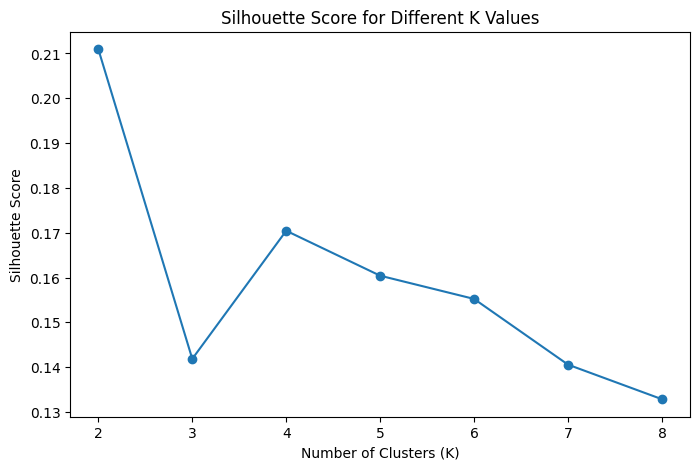

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(k_values))

plt.show()

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA shape:", X_pca.shape)

print("\nExplained variance:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_.sum())

Original features: 41
PCA shape: (397, 2)

Explained variance:
PC1: 0.25020775396551903
PC2: 0.11782608893004833
Total: 0.36803384289556734


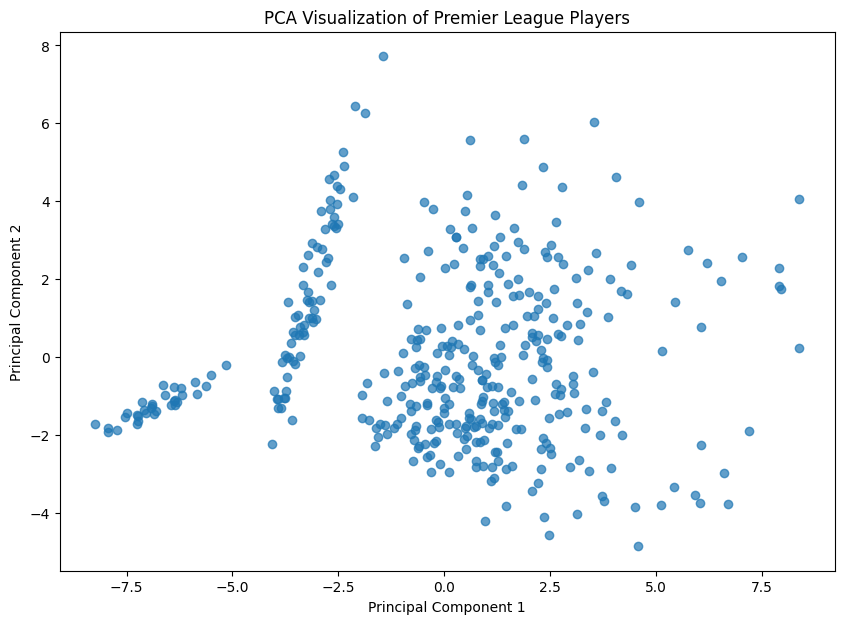

In [21]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Premier League Players")

plt.show()

In [22]:
k_values = range(2, 7)

kmeans_models = {}
cluster_labels = {}
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    kmeans_models[k] = kmeans
    cluster_labels[k] = labels

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.2109
K=3 | Silhouette Score=0.1418
K=4 | Silhouette Score=0.1704
K=5 | Silhouette Score=0.1604
K=6 | Silhouette Score=0.1552


In [23]:
kmeans_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

kmeans_results.sort_values(
    "Silhouette Score",
    ascending=False
)

,K,Silhouette Score
0,2,0.210933
2,4,0.170429
3,5,0.160403
4,6,0.155220
1,3,0.141847


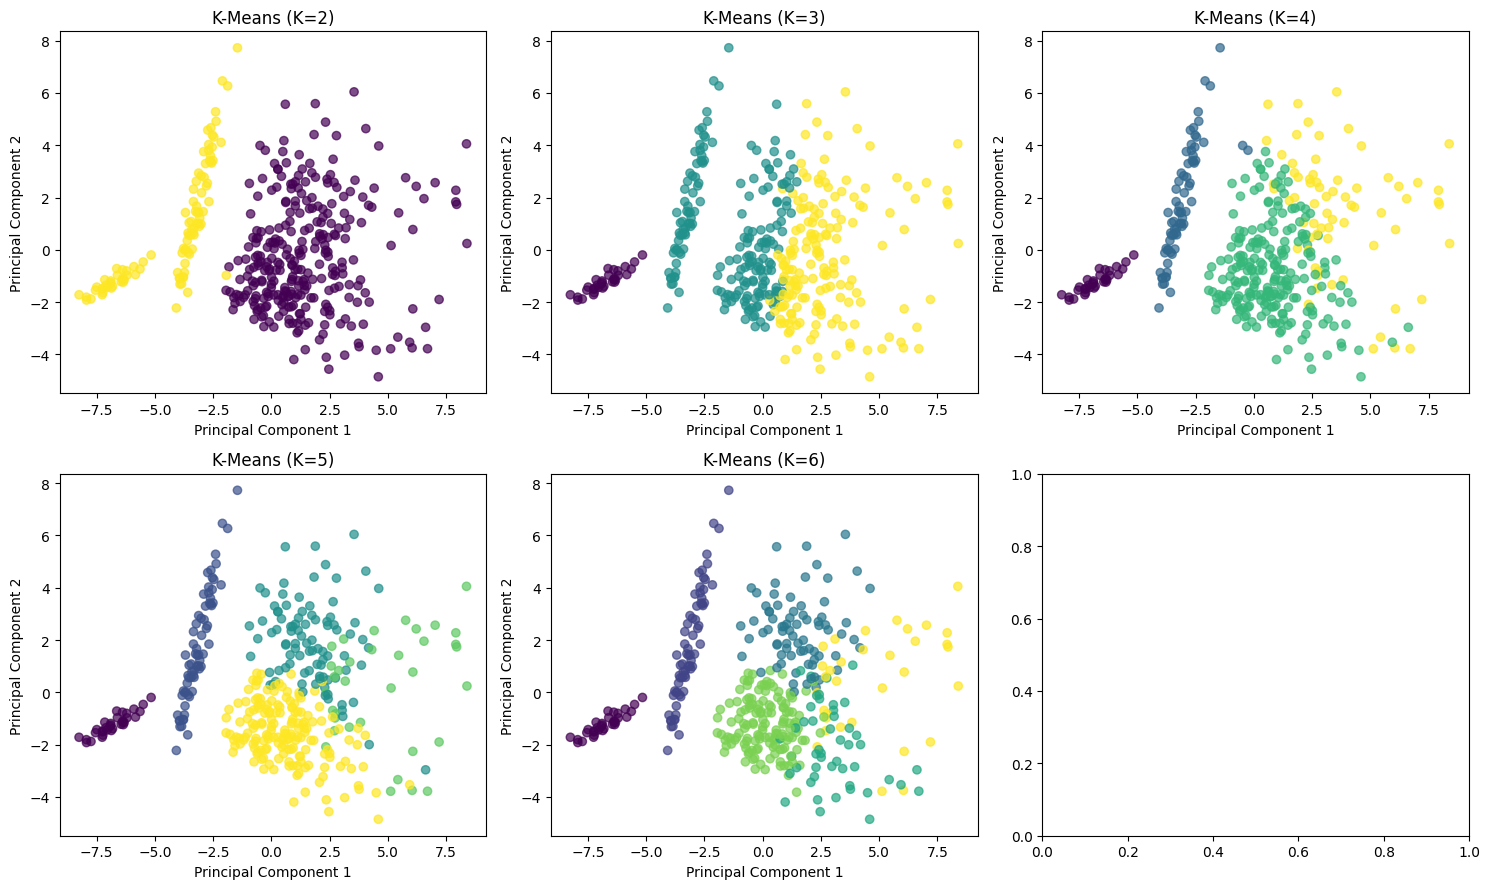

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, k in zip(axes.flatten(), k_values):
    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels[k],
        alpha=0.7
    )

    ax.set_title(f"K-Means (K={k})")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [25]:
cluster_df = df_model[["Player Name", "Club", "Position"]].copy()

for k in [2, 3, 4]:
    cluster_df[f"Cluster_K{k}"] = cluster_labels[k]

cluster_df.head()

,Player Name,Club,Position,Cluster_K2,Cluster_K3,Cluster_K4
0,Ben White,Arsenal,DEF,0,2,3
1,Bukayo Saka,Arsenal,MID,0,1,2
2,David Raya,Arsenal,GKP,1,0,0
3,Declan Rice,Arsenal,MID,0,2,3
4,Ethan Nwaneri,Arsenal,MID,1,1,1


In [26]:
for k in [2, 3, 4]:
    print(f"\nK = {k}")
    print(cluster_df[f"Cluster_K{k}"].value_counts().sort_index())


K = 2
Cluster_K2
0    294
1    103
Name: count, dtype: int64

K = 3
Cluster_K3
0     33
1    195
2    169
Name: count, dtype: int64

K = 4
Cluster_K4
0     33
1     71
2    225
3     68
Name: count, dtype: int64


In [27]:
for k in [2, 3, 4]:
    print(f"\n{'='*50}")
    print(f"K = {k}")
    print(f"{'='*50}")

    print(
        pd.crosstab(
            cluster_df[f"Cluster_K{k}"],
            cluster_df["Position"],
            normalize="index"
        ).round(2)
    )


K = 2
Position     DEF   FWD   GKP   MID
Cluster_K2                        
0           0.39  0.12  0.00  0.48
1           0.27  0.10  0.31  0.32

K = 3
Position     DEF   FWD   GKP   MID
Cluster_K3                        
0           0.00  0.00  0.97  0.03
1           0.43  0.10  0.00  0.47
2           0.36  0.15  0.01  0.49

K = 4
Position     DEF   FWD   GKP   MID
Cluster_K4                        
0           0.00  0.00  0.97  0.03
1           0.38  0.15  0.00  0.46
2           0.48  0.06  0.00  0.46
3           0.15  0.32  0.00  0.53


In [28]:
cluster_analysis = df_model.copy()

cluster_analysis["Cluster"] = cluster_labels[4]

cluster_means = (
    cluster_analysis
    .groupby("Cluster")[X_reduced.columns]
    .mean()
)

cluster_means.T

Cluster,0,1,2,3
Goals_per90,0.000000,0.153811,0.090233,0.229593
Assists_per90,0.002462,0.076723,0.072622,0.114170
Shots_per90,0.001775,1.347803,1.054218,2.072882
Shots On Target_per90,0.000000,0.008653,0.341112,1.039177
Big Chances Missed_per90,0.000000,0.160404,0.109825,0.318286
Hit Woodwork_per90,0.000797,0.030902,0.028717,0.062004
Offsides_per90,0.000000,0.212257,0.110423,0.327271
Touches_per90,41.570121,60.222645,61.697841,50.103322
Passes_per90,0.000000,0.394416,46.004256,48.970293
Crosses_per90,0.000000,0.013512,0.960492,2.562604


In [29]:
cluster_profile_scaler = StandardScaler()

cluster_profiles = pd.DataFrame(
    cluster_profile_scaler.fit_transform(cluster_means.T),
    index=cluster_means.columns,
    columns=cluster_means.index
)

cluster_profiles

Cluster,0,1,2,3
Goals_per90,-0.185433,-0.176670,-0.417545,-0.451035
Assists_per90,-0.185049,-0.184997,-0.418507,-0.457786
Shots_per90,-0.185156,-0.047700,-0.364921,-0.343221
Shots On Target_per90,-0.185433,-0.192350,-0.403849,-0.403682
Big Chances Missed_per90,-0.185433,-0.175958,-0.416476,-0.445847
Hit Woodwork_per90,-0.185309,-0.189946,-0.420903,-0.460837
Offsides_per90,-0.185433,-0.170357,-0.416443,-0.445322
Touches_per90,6.300825,6.311739,2.945654,2.466082
Passes_per90,-0.185433,-0.150681,2.088931,2.399811
Crosses_per90,-0.185433,-0.191825,-0.370037,-0.314577


In [30]:
for cluster in cluster_profiles.columns:
    print(f"\n{'=' * 50}")
    print(f"CLUSTER {cluster}")
    print(f"{'=' * 50}")

    print(
        cluster_profiles[cluster]
        .sort_values(ascending=False)
        .head(10)
    )


CLUSTER 0
Touches_per90            6.300825
Saves_per90              0.315220
Goals Conceded_per90    -0.006745
Clearances_per90        -0.016649
High Claims_per90       -0.032335
Punches_per90           -0.136179
Clean Sheets_per90      -0.152594
Yellow Cards_per90      -0.175245
Goals Prevented_per90   -0.177265
Tackles_per90           -0.178976
Name: 0, dtype: float64

CLUSTER 1
Touches_per90         6.311739
Passes%               0.053175
Clearances_per90      0.024710
Tackles_per90         0.003274
Shots_per90          -0.047700
Fouls_per90          -0.054356
Dispossessed_per90   -0.077376
aDuels %             -0.100481
Crosses %            -0.146122
Passes_per90         -0.150681
Name: 1, dtype: float64

CLUSTER 2
Passes%                 4.145674
Touches_per90           2.945654
aDuels %                2.290320
Passes_per90            2.088931
Crosses %               0.671768
fThird Passes_per90     0.209180
Carries_per90           0.196355
Conversion %            0.039730
Groun

In [31]:
hierarchical_scores = []

hierarchical_labels = {}

for k in range(2, 7):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    hierarchical_scores.append(score)
    hierarchical_labels[k] = labels

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.2060
K=3 | Silhouette Score=0.1537
K=4 | Silhouette Score=0.1464
K=5 | Silhouette Score=0.1426
K=6 | Silhouette Score=0.1369


In [32]:
hierarchical_results = pd.DataFrame({
    "K": range(2, 7),
    "Silhouette Score": hierarchical_scores
})

hierarchical_results.sort_values(
    "Silhouette Score",
    ascending=False
)

,K,Silhouette Score
0,2,0.205973
1,3,0.153660
2,4,0.146354
3,5,0.142612
4,6,0.136886


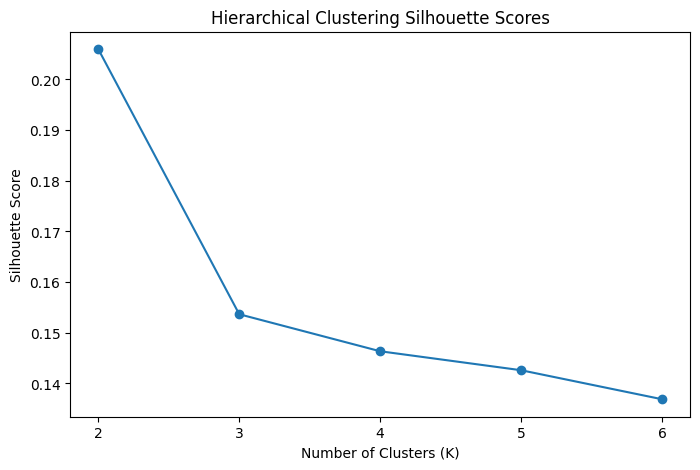

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    hierarchical_results["K"],
    hierarchical_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores")
plt.xticks(range(2, 7))

plt.show()

In [34]:
comparison = pd.DataFrame({
    "K": range(2, 7),
    "K-Means": silhouette_scores,
    "Agglomerative": hierarchical_scores
})

comparison

,K,K-Means,Agglomerative
0,2,0.210933,0.205973
1,3,0.141847,0.153660
2,4,0.170429,0.146354
3,5,0.160403,0.142612
4,6,0.155220,0.136886


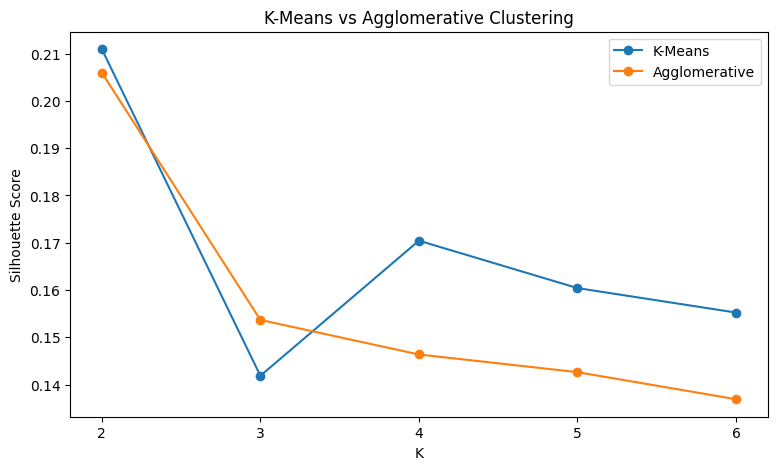

In [35]:
comparison.plot(
    x="K",
    y=["K-Means", "Agglomerative"],
    marker="o",
    figsize=(9, 5)
)

plt.ylabel("Silhouette Score")
plt.title("K-Means vs Agglomerative Clustering")
plt.xticks(range(2, 7))

plt.show()

In [36]:
cluster_profile = (
    df_model
    .assign(Cluster=cluster_labels[4])
    .groupby("Cluster")[X_reduced.columns]
    .mean()
)

cluster_profile.T

Cluster,0,1,2,3
Goals_per90,0.000000,0.153811,0.090233,0.229593
Assists_per90,0.002462,0.076723,0.072622,0.114170
Shots_per90,0.001775,1.347803,1.054218,2.072882
Shots On Target_per90,0.000000,0.008653,0.341112,1.039177
Big Chances Missed_per90,0.000000,0.160404,0.109825,0.318286
Hit Woodwork_per90,0.000797,0.030902,0.028717,0.062004
Offsides_per90,0.000000,0.212257,0.110423,0.327271
Touches_per90,41.570121,60.222645,61.697841,50.103322
Passes_per90,0.000000,0.394416,46.004256,48.970293
Crosses_per90,0.000000,0.013512,0.960492,2.562604


In [37]:
for cluster in cluster_profile.index:

    overall_mean = cluster_profile.drop(index=cluster).mean()

    difference = (
        cluster_profile.loc[cluster] - overall_mean
    ).sort_values(ascending=False)

    print(f"\n{'=' * 50}")
    print(f"CLUSTER {cluster}")
    print(f"{'=' * 50}")

    print("\nHighest distinguishing features:")
    print(difference.head(10))

    print("\nLowest distinguishing features:")
    print(difference.tail(10))


CLUSTER 0

Highest distinguishing features:
Saves_per90                  3.208666
Goals Conceded_per90         1.145205
High Claims_per90            0.981202
Punches_per90                0.315668
Clean Sheets_per90           0.103100
Goals Prevented_per90        0.052350
Penalties Saved_per90        0.015249
Own Goals_per90             -0.002697
Red Cards_per90             -0.005978
Clearances Off Line_per90   -0.007588
dtype: float64

Lowest distinguishing features:
Possession Won_per90    -3.292019
Ground Duels_per90      -6.300381
Conversion %            -6.466381
Carries_per90          -10.042459
fThird Passes_per90    -10.960722
Crosses %              -13.915257
Touches_per90          -15.771148
aDuels %               -29.203771
Passes_per90           -31.789655
Passes%                -55.962720
dtype: float64

CLUSTER 1

Highest distinguishing features:
Touches_per90               9.098883
Tackles_per90               0.751121
Fouls_per90                 0.558731
Clearances_per90

In [38]:
clustered_players = df_model.copy()

clustered_players["Cluster"] = cluster_labels[4]

clustered_players[
    ["Player Name", "Club", "Position", "Cluster"]
].sort_values("Cluster").head(20)

,Player Name,Club,Position,Cluster
556,Sam Johnstone,Wolverhampton Wanderers,GKP,0
2,David Raya,Arsenal,GKP,0
73,Mark Travers,Bournemouth,GKP,0
67,Kepa,Bournemouth,GKP,0
472,Antonín Kinsky,Tottenham Hotspur,GKP,0
96,Mark Flekken,Brentford,GKP,0
484,Guglielmo Vicario,Tottenham Hotspur,GKP,0
483,Fraser Forster,Tottenham Hotspur,GKP,0
424,Matz Sels,Nottingham Forest,GKP,0
504,Alphonse Areola,West Ham United,GKP,0


In [39]:
print("Players in each cluster:")
print(
    clustered_players["Cluster"]
    .value_counts()
    .sort_index()
)

Players in each cluster:
Cluster
0     33
1     71
2    225
3     68
Name: count, dtype: int64


In [40]:
for cluster in sorted(clustered_players["Cluster"].unique()):

    print(f"\n{'=' * 60}")
    print(f"CLUSTER {cluster}")
    print(f"{'=' * 60}")

    display(
        clustered_players[
            clustered_players["Cluster"] == cluster
        ][["Player Name", "Club", "Position"]]
        .sort_values("Player Name")
        .head(20)
    )


CLUSTER 0


,Player Name,Club,Position
437,Aaron Ramsdale,Southampton,GKP
440,Alex McCarthy,Southampton,GKP
245,Alex Palmer,Ipswich Town,MID
307,Alisson Becker,Liverpool,GKP
504,Alphonse Areola,West Ham United,GKP
364,André Onana,Manchester United,GKP
472,Antonín Kinsky,Tottenham Hotspur,GKP
247,Arijanet Muric,Ipswich Town,GKP
112,Bart Verbruggen,Brighton & Hove Albion,GKP
223,Bernd Leno,Fulham,GKP



CLUSTER 1


,Player Name,Club,Position
502,Aaron Cresswell,West Ham United,DEF
330,Abdukodir Khusanov,Manchester City,DEF
275,Abdul Fatawu,Leicester City,MID
111,Adam Webster,Brighton & Hove Albion,DEF
53,Alex Scott,Bournemouth,MID
27,Axel Disasi,Aston Villa,DEF
277,Bobby De Cordova-Reid,Leicester City,MID
114,Brajan Gruda,Brighton & Hove Albion,MID
198,Carlos Alcaraz,Everton,MID
417,Chris Wood,Nottingham Forest,FWD



CLUSTER 2


,Player Name,Club,Position
503,Aaron Wan-Bissaka,West Ham United,DEF
193,Abdoulaye Doucouré,Everton,MID
194,Adam Armstrong,Everton,FWD
52,Adam Smith,Bournemouth,DEF
167,Adam Wharton,Crystal Palace,MID
306,Alexis Mac Allister,Liverpool,MID
363,Amad Diallo,Manchester United,MID
25,Amadou Onana,Aston Villa,MID
221,Andreas Pereira,Fulham,MID
531,André,Wolverhampton Wanderers,MID



CLUSTER 3


,Player Name,Club,Position
219,Adama Traoré,Fulham,MID
361,Alejandro Garnacho,Manchester United,MID
220,Alex Iwobi,Fulham,MID
391,Alexander Isak,Newcastle United,FWD
415,Anthony Elanga,Nottingham Forest,MID
392,Anthony Gordon,Newcastle United,MID
54,Antoine Semenyo,Bournemouth,MID
0,Ben White,Arsenal,DEF
197,Beto,Everton,FWD
476,Brennan Johnson,Tottenham Hotspur,MID


In [41]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("K-MEANS vs ACTUAL POSITIONS")
print("=" * 50)

for k in k_values:
    labels = cluster_labels[k]

    ari = adjusted_rand_score(actual_positions, labels)
    nmi = normalized_mutual_info_score(actual_positions, labels)

    print(f"K = {k}")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
    print()

K-MEANS vs ACTUAL POSITIONS
K = 2
Adjusted Rand Index (ARI): 0.0984
Normalized Mutual Information (NMI): 0.1239

K = 3
Adjusted Rand Index (ARI): 0.1155
Normalized Mutual Information (NMI): 0.2523

K = 4
Adjusted Rand Index (ARI): 0.1644
Normalized Mutual Information (NMI): 0.2714

K = 5
Adjusted Rand Index (ARI): 0.2258
Normalized Mutual Information (NMI): 0.3461

K = 6
Adjusted Rand Index (ARI): 0.1741
Normalized Mutual Information (NMI): 0.3058



In [42]:
best_k = 4

df_clusters = df_model[["Player Name", "Club", "Position"]].copy()
df_clusters["Cluster"] = cluster_labels[best_k]

position_cluster_table = pd.crosstab(
    df_clusters["Cluster"],
    df_clusters["Position"],
    normalize="index"
)

print("POSITION DISTRIBUTION WITHIN EACH CLUSTER")
print(position_cluster_table.round(2))

POSITION DISTRIBUTION WITHIN EACH CLUSTER
Position   DEF   FWD   GKP   MID
Cluster                         
0         0.00  0.00  0.97  0.03
1         0.38  0.15  0.00  0.46
2         0.48  0.06  0.00  0.46
3         0.15  0.32  0.00  0.53


In [43]:
print("CLUSTER SIZES")
print("=" * 40)

print(df_clusters["Cluster"].value_counts().sort_index())

CLUSTER SIZES
Cluster
0     33
1     71
2    225
3     68
Name: count, dtype: int64


In [44]:
cluster_names = {
    0: "Goalkeepers",
    1: "Defensive / Defensive Work",
    2: "Possession / Passing",
    3: "Attacking / High Involvement"
}

df_clusters["Cluster Type"] = df_clusters["Cluster"].map(cluster_names)

df_clusters.head(20)

,Player Name,Club,Position,Cluster,Cluster Type
0,Ben White,Arsenal,DEF,3,Attacking / High Involvement
1,Bukayo Saka,Arsenal,MID,2,Possession / Passing
2,David Raya,Arsenal,GKP,0,Goalkeepers
3,Declan Rice,Arsenal,MID,3,Attacking / High Involvement
4,Ethan Nwaneri,Arsenal,MID,1,Defensive / Defensive Work
5,Gabriel Jesus,Arsenal,FWD,1,Defensive / Defensive Work
6,Gabriel Magalhães,Arsenal,DEF,2,Possession / Passing
7,Gabriel Martinelli,Arsenal,MID,3,Attacking / High Involvement
8,Jakub Kiwior,Arsenal,DEF,2,Possession / Passing
9,Jorginho,Arsenal,MID,1,Defensive / Defensive Work


In [45]:
for cluster in sorted(df_clusters["Cluster"].unique()):

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster} — {cluster_names[cluster]}")
    print("=" * 60)

    display(
        df_clusters[df_clusters["Cluster"] == cluster]
        [["Player Name", "Club", "Position"]]
        .sort_values(["Position", "Player Name"])
    )


CLUSTER 0 — Goalkeepers


,Player Name,Club,Position
437,Aaron Ramsdale,Southampton,GKP
440,Alex McCarthy,Southampton,GKP
307,Alisson Becker,Liverpool,GKP
504,Alphonse Areola,West Ham United,GKP
364,André Onana,Manchester United,GKP
472,Antonín Kinsky,Tottenham Hotspur,GKP
247,Arijanet Muric,Ipswich Town,GKP
112,Bart Verbruggen,Brighton & Hove Albion,GKP
223,Bernd Leno,Fulham,GKP
309,Caoimhín Kelleher,Liverpool,GKP



CLUSTER 1 — Defensive / Defensive Work


,Player Name,Club,Position
502,Aaron Cresswell,West Ham United,DEF
330,Abdukodir Khusanov,Manchester City,DEF
111,Adam Webster,Brighton & Hove Albion,DEF
27,Axel Disasi,Aston Villa,DEF
311,Conor Bradley,Liverpool,DEF
...,...,...,...
216,Tim Iroegbunam,Everton,MID
498,Timo Werner,Tottenham Hotspur,MID
243,Tom Cairney,Fulham,MID
559,Tommy Doyle,Wolverhampton Wanderers,MID



CLUSTER 2 — Possession / Passing


,Player Name,Club,Position
503,Aaron Wan-Bissaka,West Ham United,DEF
52,Adam Smith,Bournemouth,DEF
308,Andy Robertson,Liverpool,DEF
222,Antonee Robinson,Fulham,DEF
196,Ashley Young,Everton,DEF
...,...,...,...
192,Will Hughes,Crystal Palace,MID
137,Yankuba Minteh,Brighton & Hove Albion,MID
138,Yasin Ayari,Brighton & Hove Albion,MID
51,Youri Tielemans,Aston Villa,MID



CLUSTER 3 — Attacking / High Involvement


,Player Name,Club,Position
0,Ben White,Arsenal,DEF
279,Caleb Okoli,Leicester City,DEF
538,Emmanuel Agbadou,Wolverhampton Wanderers,DEF
122,Igor Julio,Brighton & Hove Albion,DEF
208,Jarrad Branthwaite,Everton,DEF
...,...,...,...
297,Oliver Skipp,Leicester City,MID
241,Sasa Lukic,Fulham,MID
134,Simon Adingra,Brighton & Hove Albion,MID
497,Son Heung-Min,Tottenham Hotspur,MID


In [46]:
from sklearn.metrics import pairwise_distances

labels_k4 = cluster_labels[4]

distances = pairwise_distances(
    X_scaled,
    kmeans_models[4].cluster_centers_
)

df_representative = df_model[
    ["Player Name", "Club", "Position"]
].copy()

df_representative["Cluster"] = labels_k4

df_representative["Distance_to_Centroid"] = [
    distances[i, labels_k4[i]]
    for i in range(len(labels_k4))
]

for cluster in range(4):

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster} — {cluster_names[cluster]}")
    print("=" * 60)

    display(
        df_representative[
            df_representative["Cluster"] == cluster
        ]
        .sort_values("Distance_to_Centroid")
        .head(10)
    )


CLUSTER 0 — Goalkeepers


,Player Name,Club,Position,Cluster,Distance_to_Centroid
2,David Raya,Arsenal,GKP,0,2.975200
358,Stefan Ortega,Manchester City,GKP,0,3.058287
176,Dean Henderson,Crystal Palace,GKP,0,3.306751
364,André Onana,Manchester United,GKP,0,3.392944
286,Jakub Stolarczyk,Leicester City,GKP,0,3.400045
96,Mark Flekken,Brentford,GKP,0,3.500809
32,Emiliano Martínez,Aston Villa,GKP,0,3.534170
67,Kepa,Bournemouth,GKP,0,3.603844
160,Robert Sánchez,Chelsea,GKP,0,3.762390
556,Sam Johnstone,Wolverhampton Wanderers,GKP,0,4.414714



CLUSTER 1 — Defensive / Defensive Work


,Player Name,Club,Position,Cluster,Distance_to_Centroid
237,Reiss Nelson,Fulham,MID,1,2.205529
185,Justin Devenny,Crystal Palace,MID,1,2.269927
253,Conor Chaplin,Ipswich Town,MID,1,2.325126
260,Jack Taylor,Ipswich Town,MID,1,2.457422
97,Mathias Jensen,Brentford,MID,1,2.578871
291,Kasey McAteer,Leicester City,MID,1,2.709888
27,Axel Disasi,Aston Villa,DEF,1,2.738584
64,Julián Araujo,Bournemouth,DEF,1,2.740502
39,Lamare Bogarde,Aston Villa,DEF,1,2.814527
271,Nathan Broadhead,Ipswich Town,MID,1,2.832594



CLUSTER 2 — Possession / Passing


,Player Name,Club,Position,Cluster,Distance_to_Centroid
181,Jefferson Lerma,Crystal Palace,MID,2,2.510759
551,Nélson Semedo,Wolverhampton Wanderers,DEF,2,2.557920
382,Matthijs de Ligt,Manchester United,DEF,2,2.670683
91,Keane Lewis-Potter,Brentford,MID,2,2.704563
240,Sander Berge,Fulham,MID,2,2.761130
138,Yasin Ayari,Brighton & Hove Albion,MID,2,2.784665
150,Marc Cucurella,Chelsea,DEF,2,2.879822
164,Trevoh Chalobah,Chelsea,DEF,2,2.899152
94,Kristoffer Ajer,Brentford,DEF,2,2.933607
148,Levi Colwill,Chelsea,DEF,2,2.944444



CLUSTER 3 — Attacking / High Involvement


,Player Name,Club,Position,Cluster,Distance_to_Centroid
392,Anthony Gordon,Newcastle United,MID,3,3.067799
220,Alex Iwobi,Fulham,MID,3,3.613995
458,Mateus Fernandes,Southampton,MID,3,3.657563
3,Declan Rice,Arsenal,MID,3,3.956577
375,Joshua Zirkzee,Manchester United,FWD,3,4.066435
385,Rasmus Højlund,Manchester United,FWD,3,4.108423
426,Morgan Gibbs-White,Nottingham Forest,MID,3,4.127485
361,Alejandro Garnacho,Manchester United,MID,3,4.183638
482,Dominic Solanke,Tottenham Hotspur,FWD,3,4.187480
415,Anthony Elanga,Nottingham Forest,MID,3,4.194308


In [47]:
cluster_profiles = pd.DataFrame(
    kmeans_models[4].cluster_centers_,
    columns=X_reduced.columns
)

for cluster in range(4):

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster} — {cluster_names[cluster]}")
    print("=" * 60)

    profile = cluster_profiles.loc[cluster]

    print("\nHighest features:")
    print(profile.sort_values(ascending=False).head(10))

    print("\nLowest features:")
    print(profile.sort_values().head(10))


CLUSTER 0 — Goalkeepers

Highest features:
Saves_per90                  3.252999
High Claims_per90            2.970831
Goals Conceded_per90         2.828001
Punches_per90                2.304198
Penalties Saved_per90        1.663107
Goals Prevented_per90        1.443021
Clean Sheets_per90           0.714545
Own Goals_per90             -0.162412
Red Cards_per90             -0.267370
Clearances Off Line_per90   -0.362041
Name: 0, dtype: float64

Lowest features:
Passes%                -1.680441
Tackles_per90          -1.583200
Fouls_per90            -1.560365
aDuels %               -1.463197
Dispossessed_per90     -1.224881
Shots_per90            -1.215063
Possession Won_per90   -1.109724
Ground Duels_per90     -1.105250
Touches_per90          -1.068205
Passes_per90           -1.060384
Name: 0, dtype: float64

CLUSTER 1 — Defensive / Defensive Work

Highest features:
Fouls_per90                 0.434397
Yellow Cards_per90          0.350574
Dispossessed_per90          0.264156
Offsides_p

In [48]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

labels_k4 = cluster_labels[4]

silhouette_k4 = silhouette_score(
    X_scaled,
    labels_k4
)

centroid_distances = pairwise_distances(
    kmeans_models[4].cluster_centers_
)

print("FINAL K=4 CLUSTERING")
print("=" * 50)

print(f"Silhouette Score: {silhouette_k4:.4f}")

print("\nCentroid distances:")
print(pd.DataFrame(
    centroid_distances,
    index=[f"Cluster {i}" for i in range(4)],
    columns=[f"Cluster {i}" for i in range(4)]
).round(2))

FINAL K=4 CLUSTERING
Silhouette Score: 0.1704

Centroid distances:
           Cluster 0  Cluster 1  Cluster 2  Cluster 3
Cluster 0       0.00       8.04       9.25      11.27
Cluster 1       8.04       0.00       5.23       7.81
Cluster 2       9.25       5.23       0.00       4.93
Cluster 3      11.27       7.81       4.93       0.00


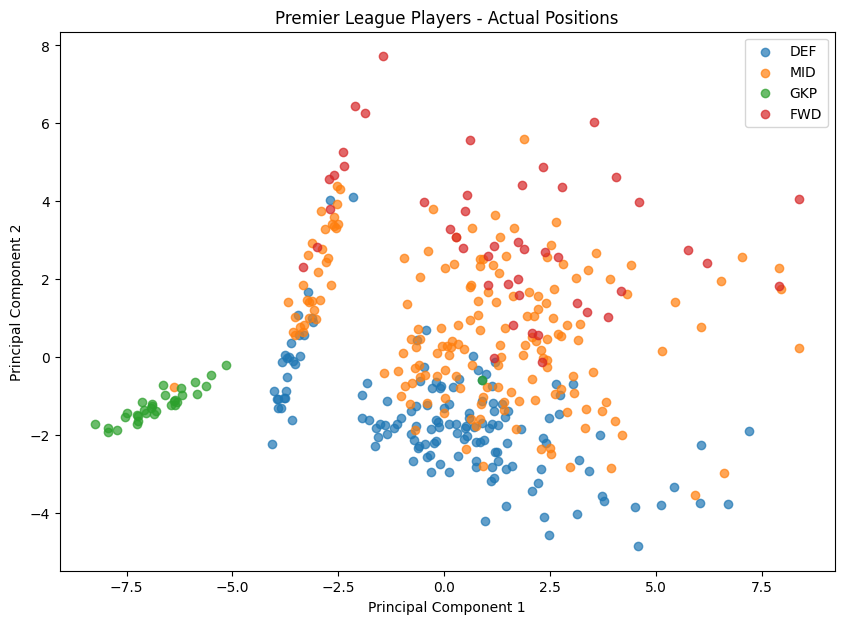

In [49]:
plt.figure(figsize=(10, 7))

for position in actual_positions.unique():

    mask = actual_positions == position

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=position,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Premier League Players - Actual Positions")
plt.legend()
plt.show()

In [50]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X_scaled)

df_model["Cluster"] = final_labels

print(df_model["Cluster"].value_counts().sort_index())

Cluster
0     33
1     71
2    225
3     68
Name: count, dtype: int64


In [51]:
cluster_sizes = (
    df_model["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

cluster_sizes["Percentage"] = (
    cluster_sizes["Count"] / len(df_model) * 100
).round(2)

cluster_sizes

,Count,Percentage
Cluster,,
0,33,8.31
1,71,17.88
2,225,56.68
3,68,17.13


In [52]:
position_distribution = pd.crosstab(
    df_model["Cluster"],
    df_model["Position"],
    normalize="index"
).round(2)

print("POSITION DISTRIBUTION WITHIN EACH CLUSTER")
position_distribution

POSITION DISTRIBUTION WITHIN EACH CLUSTER


Position,DEF,FWD,GKP,MID
Cluster,,,,
0,0.00,0.00,0.97,0.03
1,0.38,0.15,0.00,0.46
2,0.48,0.06,0.00,0.46
3,0.15,0.32,0.00,0.53


In [53]:
cluster_profiles = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=X_reduced.columns
)

cluster_profiles.index.name = "Cluster"

cluster_profiles

,Goals_per90,Assists_per90,Shots_per90,Shots On Target_per90,Big Chances Missed_per90,Hit Woodwork_per90,Offsides_per90,Touches_per90,Passes_per90,Crosses_per90,...,Saves_per90,Penalties Saved_per90,Clearances Off Line_per90,Punches_per90,High Claims_per90,Goals Prevented_per90,Conversion %,Passes%,Crosses %,aDuels %
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.733169,-0.675602,-1.215063,-0.708226,-0.742221,-0.587521,-0.696344,-1.068205,-1.060384,-0.709583,...,3.252999,1.663107,-0.362041,2.304198,2.970831,1.443021,-0.822662,-1.680441,-0.926075,-1.463197
1,0.222722,0.019500,0.157069,-0.691792,0.076320,-0.029411,0.247493,0.161348,-1.048272,-0.699855,...,-0.294915,-0.150776,-0.002454,-0.208897,-0.269334,-0.130823,-0.798351,-1.618465,-0.899263,-1.426933
2,-0.172398,-0.018891,-0.142209,-0.060318,-0.181782,-0.069918,-0.205331,0.258591,0.352309,-0.018154,...,-0.294915,-0.150776,0.142404,-0.208897,-0.269334,-0.130823,0.221198,0.592507,0.304821,0.634341
3,0.693689,0.370013,0.896210,1.265591,0.881992,0.547175,0.758923,-0.505706,0.443390,1.135157,...,-0.294915,-0.150776,-0.292931,-0.208897,-0.269334,-0.130823,0.500899,0.544877,0.379756,0.101043


In [54]:
for cluster in cluster_profiles.index:

    print("=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)

    profile = cluster_profiles.loc[cluster]

    print("\nHighest distinguishing features:")
    print(profile.sort_values(ascending=False).head(10))

    print("\nLowest distinguishing features:")
    print(profile.sort_values().head(10))

CLUSTER 0

Highest distinguishing features:
Saves_per90                  3.252999
High Claims_per90            2.970831
Goals Conceded_per90         2.828001
Punches_per90                2.304198
Penalties Saved_per90        1.663107
Goals Prevented_per90        1.443021
Clean Sheets_per90           0.714545
Own Goals_per90             -0.162412
Red Cards_per90             -0.267370
Clearances Off Line_per90   -0.362041
Name: 0, dtype: float64

Lowest distinguishing features:
Passes%                -1.680441
Tackles_per90          -1.583200
Fouls_per90            -1.560365
aDuels %               -1.463197
Dispossessed_per90     -1.224881
Shots_per90            -1.215063
Possession Won_per90   -1.109724
Ground Duels_per90     -1.105250
Touches_per90          -1.068205
Passes_per90           -1.060384
Name: 0, dtype: float64
CLUSTER 1

Highest distinguishing features:
Fouls_per90                 0.434397
Yellow Cards_per90          0.350574
Dispossessed_per90          0.264156
Offsides_p

In [55]:
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(
    X_scaled,
    final_kmeans.cluster_centers_
)

df_model["Distance_to_Centroid"] = (
    distances[
        np.arange(len(X_scaled)),
        final_labels
    ]
)

for cluster in range(4):

    print("=" * 60)
    print(f"CLUSTER {cluster} — Closest Players")
    print("=" * 60)

    display(
        df_model[
            df_model["Cluster"] == cluster
        ][
            ["Player Name", "Club", "Position", "Cluster",
             "Distance_to_Centroid"]
        ]
        .sort_values("Distance_to_Centroid")
        .head(10)
    )

CLUSTER 0 — Closest Players


,Player Name,Club,Position,Cluster,Distance_to_Centroid
2,David Raya,Arsenal,GKP,0,2.975200
358,Stefan Ortega,Manchester City,GKP,0,3.058287
176,Dean Henderson,Crystal Palace,GKP,0,3.306751
364,André Onana,Manchester United,GKP,0,3.392944
286,Jakub Stolarczyk,Leicester City,GKP,0,3.400045
96,Mark Flekken,Brentford,GKP,0,3.500809
32,Emiliano Martínez,Aston Villa,GKP,0,3.534170
67,Kepa,Bournemouth,GKP,0,3.603844
160,Robert Sánchez,Chelsea,GKP,0,3.762390
556,Sam Johnstone,Wolverhampton Wanderers,GKP,0,4.414714


CLUSTER 1 — Closest Players


,Player Name,Club,Position,Cluster,Distance_to_Centroid
237,Reiss Nelson,Fulham,MID,1,2.205529
185,Justin Devenny,Crystal Palace,MID,1,2.269927
253,Conor Chaplin,Ipswich Town,MID,1,2.325126
260,Jack Taylor,Ipswich Town,MID,1,2.457422
97,Mathias Jensen,Brentford,MID,1,2.578871
291,Kasey McAteer,Leicester City,MID,1,2.709888
27,Axel Disasi,Aston Villa,DEF,1,2.738584
64,Julián Araujo,Bournemouth,DEF,1,2.740502
39,Lamare Bogarde,Aston Villa,DEF,1,2.814527
271,Nathan Broadhead,Ipswich Town,MID,1,2.832594


CLUSTER 2 — Closest Players


,Player Name,Club,Position,Cluster,Distance_to_Centroid
181,Jefferson Lerma,Crystal Palace,MID,2,2.510759
551,Nélson Semedo,Wolverhampton Wanderers,DEF,2,2.557920
382,Matthijs de Ligt,Manchester United,DEF,2,2.670683
91,Keane Lewis-Potter,Brentford,MID,2,2.704563
240,Sander Berge,Fulham,MID,2,2.761130
138,Yasin Ayari,Brighton & Hove Albion,MID,2,2.784665
150,Marc Cucurella,Chelsea,DEF,2,2.879822
164,Trevoh Chalobah,Chelsea,DEF,2,2.899152
94,Kristoffer Ajer,Brentford,DEF,2,2.933607
148,Levi Colwill,Chelsea,DEF,2,2.944444


CLUSTER 3 — Closest Players


,Player Name,Club,Position,Cluster,Distance_to_Centroid
392,Anthony Gordon,Newcastle United,MID,3,3.067799
220,Alex Iwobi,Fulham,MID,3,3.613995
458,Mateus Fernandes,Southampton,MID,3,3.657563
3,Declan Rice,Arsenal,MID,3,3.956577
375,Joshua Zirkzee,Manchester United,FWD,3,4.066435
385,Rasmus Højlund,Manchester United,FWD,3,4.108423
426,Morgan Gibbs-White,Nottingham Forest,MID,3,4.127485
361,Alejandro Garnacho,Manchester United,MID,3,4.183638
482,Dominic Solanke,Tottenham Hotspur,FWD,3,4.187480
415,Anthony Elanga,Nottingham Forest,MID,3,4.194308


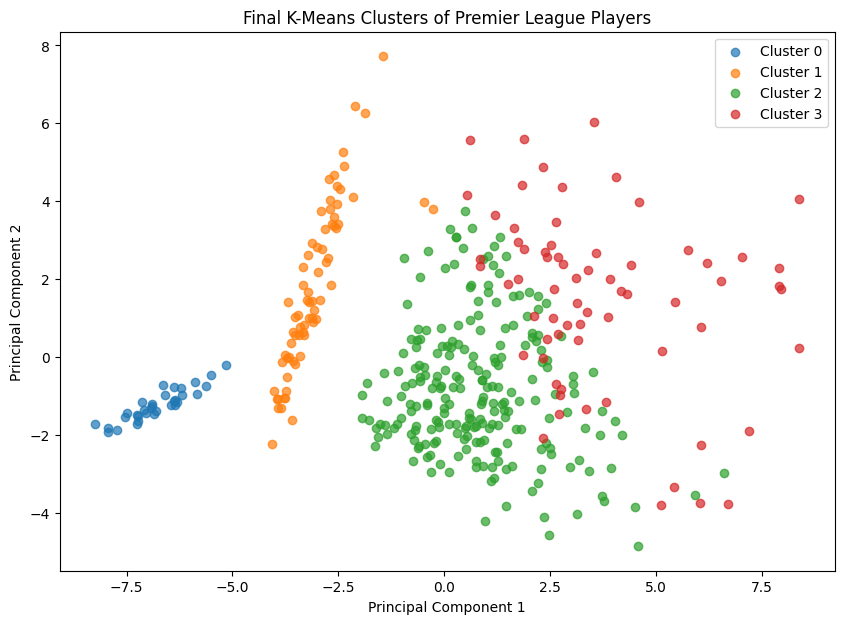

In [56]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for cluster in range(4):

    mask = final_labels == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final K-Means Clusters of Premier League Players")
plt.legend()

plt.show()

In [57]:
cluster_position_counts = pd.crosstab(
    df_model["Cluster"],
    df_model["Position"]
)

print("Cluster vs Actual Position")
cluster_position_counts

Cluster vs Actual Position


Position,DEF,FWD,GKP,MID
Cluster,,,,
0,0,0,32,1
1,27,11,0,33
2,107,13,1,104
3,10,22,0,36


In [58]:
centroid_distances = pairwise_distances(
    final_kmeans.cluster_centers_
)

centroid_distance_df = pd.DataFrame(
    centroid_distances,
    index=[f"Cluster {i}" for i in range(4)],
    columns=[f"Cluster {i}" for i in range(4)]
)

centroid_distance_df.round(2)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Cluster 0,0.00,8.04,9.25,11.27
Cluster 1,8.04,0.00,5.23,7.81
Cluster 2,9.25,5.23,0.00,4.93
Cluster 3,11.27,7.81,4.93,0.00


In [59]:
final_output = df_model[
    [
        "Player Name",
        "Club",
        "Position",
        "Cluster",
        "Distance_to_Centroid"
    ]
].copy()

final_output.to_csv(
    "premier_league_player_clusters.csv",
    index=False
)

print("Saved: premier_league_player_clusters.csv")

Saved: premier_league_player_clusters.csv


## Deep Unsupervised Learning - Autoencoder

In [60]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

In [61]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [62]:
X_autoencoder = X_reduced.copy()

print("Shape:", X_autoencoder.shape)

Shape: (397, 41)


In [63]:
X_train_ae, X_val_ae = train_test_split(X_autoencoder,test_size=0.20,random_state=42
)

print("Training:", X_train_ae.shape)
print("Validation:", X_val_ae.shape)

Training: (317, 41)
Validation: (80, 41)


In [64]:
X_train_tensor = torch.tensor(X_train_ae.values,dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_ae.values,dtype=torch.float32)

print("Training tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)

Training tensor: torch.Size([317, 41])
Validation tensor: torch.Size([80, 41])


In [65]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [66]:
class PlayerAutoencoder(nn.Module):

    def __init__(self, input_dim=41, latent_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        return reconstructed

In [67]:
model = PlayerAutoencoder(input_dim=X_train_tensor.shape[1],latent_dim=8).to(device)

print(model)

PlayerAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=41, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=41, bias=True)
  )
)


In [68]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [72]:
epochs = 1000

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            reconstructed = model(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item() * batch.size(0)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

Epoch  10 | Train Loss: 13.576804 | Val Loss: 11.090836
Epoch  20 | Train Loss: 13.513554 | Val Loss: 11.224575
Epoch  30 | Train Loss: 13.110445 | Val Loss: 10.864340
Epoch  40 | Train Loss: 12.370234 | Val Loss: 10.100744
Epoch  50 | Train Loss: 10.853377 | Val Loss: 8.486003
Epoch  60 | Train Loss: 10.199541 | Val Loss: 8.329383
Epoch  70 | Train Loss: 9.660102 | Val Loss: 8.404999
Epoch  80 | Train Loss: 9.220570 | Val Loss: 8.611590
Epoch  90 | Train Loss: 8.933013 | Val Loss: 8.481715
Epoch 100 | Train Loss: 8.771684 | Val Loss: 8.625259
Epoch 110 | Train Loss: 8.724191 | Val Loss: 8.631156
Epoch 120 | Train Loss: 8.584135 | Val Loss: 8.544034
Epoch 130 | Train Loss: 8.451991 | Val Loss: 8.559602
Epoch 140 | Train Loss: 8.269867 | Val Loss: 8.271112
Epoch 150 | Train Loss: 6.906403 | Val Loss: 7.004676
Epoch 160 | Train Loss: 5.196522 | Val Loss: 5.520642
Epoch 170 | Train Loss: 4.902930 | Val Loss: 5.424677
Epoch 180 | Train Loss: 4.799132 | Val Loss: 5.331781
Epoch 190 | Train 

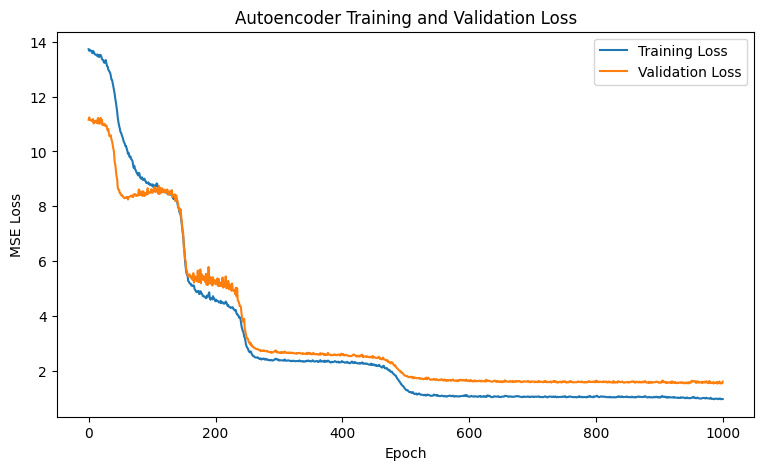

In [73]:
plt.figure(figsize=(9, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()

plt.show()

In [74]:
model.eval()

with torch.no_grad():

    X_all_tensor = torch.tensor(
        X_autoencoder.values,
        dtype=torch.float32
    ).to(device)

    embeddings = model.encoder(X_all_tensor)

embeddings = embeddings.cpu().numpy()

print("Embedding shape:", embeddings.shape)

Embedding shape: (397, 8)


In [75]:
best_epoch = np.argmin(val_losses)

print("Best epoch:", best_epoch + 1)
print("Best training loss:", train_losses[best_epoch])
print("Best validation loss:", val_losses[best_epoch])

Best epoch: 992
Best training loss: 0.9770002308704123
Best validation loss: 1.5348180294036866


In [77]:
class ImprovedPlayerAutoencoder(nn.Module):
    def __init__(self, input_dim=41, latent_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        return reconstructed

In [79]:
improved_model = ImprovedPlayerAutoencoder(
    input_dim=X_train_tensor.shape[1],
    latent_dim=8
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

epochs = 1000
patience = 30

train_losses_improved = []
val_losses_improved = []

best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(epochs):

    improved_model.train()
    train_loss = 0.0

    for (batch,) in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed = improved_model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)

    train_loss /= len(train_loader.dataset)

    improved_model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for (batch,) in val_loader:

            batch = batch.to(device)

            reconstructed = improved_model(batch)

            loss = criterion(reconstructed, batch)

            val_loss += loss.item() * batch.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses_improved.append(train_loss)
    val_losses_improved.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in improved_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

Epoch  25 | Train Loss: 43.6224 | Val Loss: 39.6161
Epoch  50 | Train Loss: 24.8692 | Val Loss: 16.4616
Epoch  75 | Train Loss: 20.3098 | Val Loss: 21.4975

Early stopping at epoch 87


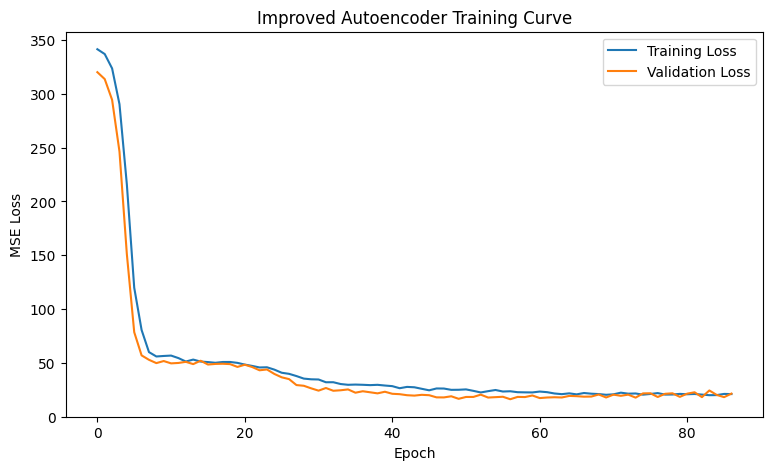

In [80]:
plt.figure(figsize=(9, 5))

plt.plot(
    train_losses_improved,
    label="Training Loss"
)

plt.plot(
    val_losses_improved,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Improved Autoencoder Training Curve")
plt.legend()

plt.show()

In [81]:
best_epoch = np.argmin(val_losses_improved)

print("Best epoch:", best_epoch + 1)
print("Best training loss:", train_losses_improved[best_epoch])
print("Best validation loss:", val_losses_improved[best_epoch])

print("\nLast epoch trained:", len(val_losses_improved))

Best epoch: 57
Best training loss: 23.481151965890398
Best validation loss: 16.0774206161499

Last epoch trained: 87


In [82]:
improved_model.eval()

with torch.no_grad():
    X_all_tensor = torch.tensor(
        X_autoencoder.values,
        dtype=torch.float32
    ).to(device)

    embeddings = improved_model.encoder(X_all_tensor).cpu().numpy()

print("Embedding shape:", embeddings.shape)

Embedding shape: (397, 8)


In [83]:
X_autoencoder = X_reduced.copy()

X_train_ae, X_val_ae = train_test_split(
    X_scaled,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_ae.shape)
print("Validation:", X_val_ae.shape)

Training: (317, 41)
Validation: (80, 41)


In [84]:
X_train_tensor = torch.tensor(
    X_train_ae,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_ae,
    dtype=torch.float32
)

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [85]:
improved_model = ImprovedPlayerAutoencoder(
    input_dim=X_train_tensor.shape[1],
    latent_dim=8
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

epochs = 500
patience = 30

train_losses_improved = []
val_losses_improved = []

best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(epochs):

    improved_model.train()
    train_loss = 0.0

    for (batch,) in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed = improved_model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)

    train_loss /= len(train_loader.dataset)

    improved_model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for (batch,) in val_loader:

            batch = batch.to(device)

            reconstructed = improved_model(batch)

            loss = criterion(reconstructed, batch)

            val_loss += loss.item() * batch.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses_improved.append(train_loss)
    val_losses_improved.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in improved_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

improved_model.load_state_dict(best_state)

print("Best validation loss:", best_val_loss)

Epoch  25 | Train: 0.5154 | Val: 0.4953
Epoch  50 | Train: 0.4747 | Val: 0.4606
Epoch  75 | Train: 0.4417 | Val: 0.4450
Epoch 100 | Train: 0.4364 | Val: 0.4356
Epoch 125 | Train: 0.4350 | Val: 0.4312
Epoch 150 | Train: 0.4243 | Val: 0.4273
Epoch 175 | Train: 0.4174 | Val: 0.4234
Epoch 200 | Train: 0.4080 | Val: 0.4180
Epoch 225 | Train: 0.4024 | Val: 0.4095
Epoch 250 | Train: 0.3884 | Val: 0.4101
Epoch 275 | Train: 0.3929 | Val: 0.4034
Epoch 300 | Train: 0.3865 | Val: 0.3980
Epoch 325 | Train: 0.3890 | Val: 0.4005
Epoch 350 | Train: 0.3686 | Val: 0.4057
Epoch 375 | Train: 0.3891 | Val: 0.3960
Epoch 400 | Train: 0.3628 | Val: 0.3984
Early stopping at epoch 408
Best validation loss: 0.3930298209190369


In [86]:
improved_model.eval()

with torch.no_grad():
    X_all_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    embeddings = (
        improved_model.encoder(X_all_tensor)
        .cpu()
        .numpy()
    )

print("Embedding shape:", embeddings.shape)

Embedding shape: (397, 8)


In [87]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (397, 397)


In [89]:
player_names = df_model["Player Name"].values

def find_similar_players(player_name, top_k=10):

    matches = np.where(player_names == player_name)[0]

    if len(matches) == 0:
        raise ValueError(f"Player not found: {player_name}")

    idx = matches[0]

    scores = similarity_matrix[idx].copy()

    scores[idx] = -1

    top_indices = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame({
        "Player": player_names[top_indices],
        "Club": df_model.iloc[top_indices]["Club"].values,
        "Position": df_model.iloc[top_indices]["Position"].values,
        "Similarity": scores[top_indices]
    })

In [90]:
find_similar_players(
    "Bukayo Saka",
    top_k=10
)

,Player,Club,Position,Similarity
0,Cameron Archer,Southampton,FWD,0.991971
1,Erling Haaland,Manchester City,FWD,0.991744
2,Evanilson,Bournemouth,FWD,0.986987
3,Ismaïla Sarr,Crystal Palace,MID,0.984466
4,Cole Palmer,Chelsea,MID,0.966157
5,Jarrod Bowen,West Ham United,MID,0.960931
6,Jamie Vardy,Leicester City,FWD,0.952681
7,Chris Wood,Nottingham Forest,FWD,0.935445
8,Emile Smith Rowe,Fulham,MID,0.928218
9,Omari Hutchinson,Ipswich Town,MID,0.894904


In [91]:
baseline_similarity = cosine_similarity(X_scaled)

def find_similar_baseline(player_name, top_k=10):

    matches = np.where(
        df_model["Player Name"].values == player_name
    )[0]

    if len(matches) == 0:
        raise ValueError(f"Player not found: {player_name}")

    idx = matches[0]

    scores = baseline_similarity[idx].copy()
    scores[idx] = -1

    top_indices = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame({
        "Player": df_model.iloc[top_indices]["Player Name"].values,
        "Club": df_model.iloc[top_indices]["Club"].values,
        "Position": df_model.iloc[top_indices]["Position"].values,
        "Similarity": scores[top_indices]
    })

In [92]:
print("BASELINE - Standardized Features")
display(
    find_similar_baseline(
        "Bukayo Saka",
        top_k=10
    )
)

print("\nAUTOENCODER - 8D Embeddings")
display(
    find_similar_players(
        "Bukayo Saka",
        top_k=10
    )
)

BASELINE - Standardized Features


,Player,Club,Position,Similarity
0,Gonçalo Guedes,Wolverhampton Wanderers,MID,0.712319
1,Cole Palmer,Chelsea,MID,0.686017
2,Morgan Rogers,Aston Villa,MID,0.655258
3,Jarrod Bowen,West Ham United,MID,0.647525
4,Jacob Murphy,Newcastle United,MID,0.600911
5,Emile Smith Rowe,Fulham,MID,0.600561
6,Mohamed Salah,Liverpool,MID,0.593613
7,Eberechi Eze,Crystal Palace,MID,0.591648
8,Ollie Watkins,Aston Villa,FWD,0.591227
9,Leandro Trossard,Arsenal,MID,0.581332



AUTOENCODER - 8D Embeddings


,Player,Club,Position,Similarity
0,Cameron Archer,Southampton,FWD,0.991971
1,Erling Haaland,Manchester City,FWD,0.991744
2,Evanilson,Bournemouth,FWD,0.986987
3,Ismaïla Sarr,Crystal Palace,MID,0.984466
4,Cole Palmer,Chelsea,MID,0.966157
5,Jarrod Bowen,West Ham United,MID,0.960931
6,Jamie Vardy,Leicester City,FWD,0.952681
7,Chris Wood,Nottingham Forest,FWD,0.935445
8,Emile Smith Rowe,Fulham,MID,0.928218
9,Omari Hutchinson,Ipswich Town,MID,0.894904


In [93]:
def position_consistency(
    similarity_matrix,
    player_name,
    k=10
):

    names = df_model["Player Name"].values
    positions = df_model["Position"].values

    matches = np.where(names == player_name)[0]

    if len(matches) == 0:
        raise ValueError(f"Player not found: {player_name}")

    idx = matches[0]

    scores = similarity_matrix[idx].copy()
    scores[idx] = -1

    top_indices = np.argsort(scores)[::-1][:k]

    same_position = (
        positions[top_indices] == positions[idx]
    )

    return same_position.mean()

In [94]:
players_to_test = [
    "Bukayo Saka",
    "Erling Haaland",
    "Declan Rice",
    "David Raya"
]

print("Position consistency @ 10")
print("=" * 40)

for player in players_to_test:

    baseline_score = position_consistency(
        baseline_similarity,
        player,
        k=10
    )

    autoencoder_score = position_consistency(
        similarity_matrix,
        player,
        k=10
    )

    print(
        f"{player}: "
        f"Baseline={baseline_score:.2f}, "
        f"Autoencoder={autoencoder_score:.2f}"
    )

Position consistency @ 10
Bukayo Saka: Baseline=0.90, Autoencoder=0.50
Erling Haaland: Baseline=0.70, Autoencoder=0.50
Declan Rice: Baseline=0.70, Autoencoder=0.90
David Raya: Baseline=1.00, Autoencoder=1.00


In [95]:
def similarity_stats(similarity_matrix, player_name):

    names = df_model["Player Name"].values
    idx = np.where(names == player_name)[0][0]

    scores = similarity_matrix[idx].copy()
    scores[idx] = np.nan

    return {
        "mean": np.nanmean(scores),
        "median": np.nanmedian(scores),
        "std": np.nanstd(scores),
        "min": np.nanmin(scores),
        "max": np.nanmax(scores)
    }


for player in players_to_test:

    baseline_stats = similarity_stats(
        baseline_similarity,
        player
    )

    autoencoder_stats = similarity_stats(
        similarity_matrix,
        player
    )

    print(f"\n{player}")
    print("Baseline:", baseline_stats)
    print("Autoencoder:", autoencoder_stats)


Bukayo Saka
Baseline: {'mean': np.float64(0.004490992215575278), 'median': np.float64(-0.05918363160029394), 'std': np.float64(0.2555385679152259), 'min': np.float64(-0.4855849299174503), 'max': np.float64(0.7123189357989318)}
Autoencoder: {'mean': np.float32(0.19519094), 'median': np.float32(0.1702231), 'std': np.float32(0.36811778), 'min': np.float32(-0.5674114), 'max': np.float32(0.99197066)}

Erling Haaland
Baseline: {'mean': np.float64(-0.007603682748626277), 'median': np.float64(-0.06788781519389388), 'std': np.float64(0.2642315823668687), 'min': np.float64(-0.5065689360951037), 'max': np.float64(0.7717237326027265)}
Autoencoder: {'mean': np.float32(0.19661577), 'median': np.float32(0.15643969), 'std': np.float32(0.3660359), 'min': np.float32(-0.529138), 'max': np.float32(0.99576956)}

Declan Rice
Baseline: {'mean': np.float64(-0.007228501513051721), 'median': np.float64(-0.05174010691132622), 'std': np.float64(0.27156837732151873), 'min': np.float64(-0.4426905713859261), 'max':

In [96]:
evaluation_players = [
    "Bukayo Saka",
    "Erling Haaland",
    "Declan Rice",
    "David Raya",
    "Bruno Fernandes",
    "Virgil van Dijk"
]

benchmark_results = []

for player in evaluation_players:

    baseline = position_consistency(
        baseline_similarity,
        player,
        k=10
    )

    autoencoder = position_consistency(
        similarity_matrix,
        player,
        k=10
    )

    benchmark_results.append({
        "Player": player,
        "Baseline": baseline,
        "Autoencoder": autoencoder
    })

benchmark_df = pd.DataFrame(benchmark_results)

benchmark_df

,Player,Baseline,Autoencoder
0,Bukayo Saka,0.9,0.5
1,Erling Haaland,0.7,0.5
2,Declan Rice,0.7,0.9
3,David Raya,1.0,1.0
4,Bruno Fernandes,0.9,0.9
5,Virgil van Dijk,1.0,1.0


## Siamese + Triplet

In [97]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(X_scaled))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=actual_positions
)

X_metric_train = X_scaled[train_idx]
X_metric_val = X_scaled[val_idx]

y_metric_train = actual_positions.iloc[train_idx].values
y_metric_val = actual_positions.iloc[val_idx].values

print("Metric training:", X_metric_train.shape)
print("Metric validation:", X_metric_val.shape)

Metric training: (317, 41)
Metric validation: (80, 41)


In [99]:
from torch.utils.data import Dataset
import random

class PairDataset(Dataset):

    def __init__(self, X, y, pairs_per_epoch=5000):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = np.array(y)
        self.pairs_per_epoch = pairs_per_epoch

        self.class_indices = {
            label: np.where(self.y == label)[0]
            for label in np.unique(self.y)
        }

        self.labels = list(self.class_indices.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def __getitem__(self, idx):

        same = random.random() < 0.5

        if same:
            label = random.choice(self.labels)
            i, j = np.random.choice(
                self.class_indices[label],
                size=2,
                replace=False
            )
            target = 1.0

        else:
            label1, label2 = random.sample(self.labels, 2)

            i = random.choice(self.class_indices[label1])
            j = random.choice(self.class_indices[label2])

            target = 0.0

        return self.X[i], self.X[j], torch.tensor(target)

In [100]:
class EmbeddingNetwork(nn.Module):

    def __init__(self, input_dim=41, embedding_dim=8):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, embedding_dim)
        )

    def forward(self, x):
        return self.network(x)


class SiameseNetwork(nn.Module):

    def __init__(self, input_dim=41, embedding_dim=8):
        super().__init__()

        self.embedding_network = EmbeddingNetwork(
            input_dim,
            embedding_dim
        )

    def forward(self, x1, x2):

        z1 = self.embedding_network(x1)
        z2 = self.embedding_network(x2)

        return z1, z2

In [101]:
class ContrastiveLoss(nn.Module):

    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z1, z2, target):

        distance = torch.nn.functional.pairwise_distance(
            z1, z2
        )

        loss = (
            target * distance.pow(2)
            +
            (1 - target) *
            torch.clamp(self.margin - distance, min=0).pow(2)
        )

        return loss.mean()

In [103]:
pair_dataset = PairDataset(
    X_metric_train,
    y_metric_train,
    pairs_per_epoch=5000
)

pair_loader = DataLoader(
    pair_dataset,
    batch_size=64,
    shuffle=True
)

siamese = SiameseNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=8
).to(device)

criterion = ContrastiveLoss(margin=1.0)

optimizer = torch.optim.Adam(
    siamese.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

siamese_losses = []

for epoch in range(100):

    siamese.train()
    epoch_loss = 0.0

    for x1, x2, target in pair_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        z1, z2 = siamese(x1, x2)

        loss = criterion(z1, z2, target)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(pair_loader)
    siamese_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch  10 | Loss: 0.0317
Epoch  20 | Loss: 0.0149
Epoch  30 | Loss: 0.0087
Epoch  40 | Loss: 0.0058
Epoch  50 | Loss: 0.0039
Epoch  60 | Loss: 0.0033
Epoch  70 | Loss: 0.0029
Epoch  80 | Loss: 0.0021
Epoch  90 | Loss: 0.0012
Epoch 100 | Loss: 0.0013


In [104]:
siamese.eval()

with torch.no_grad():

    val_tensor = torch.tensor(
        X_metric_val,
        dtype=torch.float32
    ).to(device)

    siamese_embeddings = (
        siamese.embedding_network(val_tensor)
        .cpu()
        .numpy()
    )

print("Siamese embedding shape:", siamese_embeddings.shape)

Siamese embedding shape: (80, 8)


In [105]:
class TripletDataset(Dataset):

    def __init__(self, X, y, triplets_per_epoch=5000):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = np.array(y)
        self.triplets_per_epoch = triplets_per_epoch

        self.class_indices = {
            label: np.where(self.y == label)[0]
            for label in np.unique(self.y)
        }

        self.labels = list(self.class_indices.keys())

    def __len__(self):
        return self.triplets_per_epoch

    def __getitem__(self, idx):

        label = random.choice(self.labels)

        anchor, positive = np.random.choice(
            self.class_indices[label],
            size=2,
            replace=False
        )

        negative_label = random.choice(
            [x for x in self.labels if x != label]
        )

        negative = random.choice(
            self.class_indices[negative_label]
        )

        return (
            self.X[anchor],
            self.X[positive],
            self.X[negative]
        )

In [106]:
triplet_dataset = TripletDataset(
    X_metric_train,
    y_metric_train,
    triplets_per_epoch=5000
)

triplet_loader = DataLoader(
    triplet_dataset,
    batch_size=64,
    shuffle=True
)

triplet_model = EmbeddingNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=8
).to(device)

triplet_loss = nn.TripletMarginLoss(
    margin=1.0,
    p=2
)

optimizer = torch.optim.Adam(
    triplet_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

triplet_losses = []

for epoch in range(100):

    triplet_model.train()
    epoch_loss = 0.0

    for anchor, positive, negative in triplet_loader:

        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        z_anchor = triplet_model(anchor)
        z_positive = triplet_model(positive)
        z_negative = triplet_model(negative)

        loss = triplet_loss(
            z_anchor,
            z_positive,
            z_negative
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(triplet_loader)
    triplet_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch  10 | Loss: 0.0451
Epoch  20 | Loss: 0.0159
Epoch  30 | Loss: 0.0085
Epoch  40 | Loss: 0.0066
Epoch  50 | Loss: 0.0042
Epoch  60 | Loss: 0.0032
Epoch  70 | Loss: 0.0044
Epoch  80 | Loss: 0.0018
Epoch  90 | Loss: 0.0019
Epoch 100 | Loss: 0.0023


In [107]:
triplet_model.eval()

with torch.no_grad():

    val_tensor = torch.tensor(
        X_metric_val,
        dtype=torch.float32
    ).to(device)

    triplet_embeddings = (
        triplet_model(val_tensor)
        .cpu()
        .numpy()
    )

print("Triplet embedding shape:", triplet_embeddings.shape)

Triplet embedding shape: (80, 8)


In [108]:
from sklearn.metrics.pairwise import cosine_similarity

baseline_val_similarity = cosine_similarity(X_metric_val)
siamese_similarity = cosine_similarity(siamese_embeddings)
triplet_similarity = cosine_similarity(triplet_embeddings)

In [109]:
def position_consistency_val(
    similarity_matrix,
    player_idx,
    positions,
    k=10
):

    scores = similarity_matrix[player_idx].copy()

    scores[player_idx] = -1

    top_indices = np.argsort(scores)[::-1][:k]

    return np.mean(
        positions[top_indices] == positions[player_idx]
    )


benchmark = []

for name, sim_matrix in [
    ("Standardized Features", baseline_val_similarity),
    ("Siamese Network", siamese_similarity),
    ("Triplet Network", triplet_similarity)
]:

    scores = []

    for i in range(len(y_metric_val)):

        scores.append(
            position_consistency_val(
                sim_matrix,
                i,
                y_metric_val,
                k=10
            )
        )

    benchmark.append({
        "Representation": name,
        "Mean Position Consistency@10": np.mean(scores)
    })

metric_benchmark = pd.DataFrame(benchmark)

metric_benchmark.sort_values(
    "Mean Position Consistency@10",
    ascending=False
)

,Representation,Mean Position Consistency@10
1,Siamese Network,0.67500
2,Triplet Network,0.58625
0,Standardized Features,0.55375


In [110]:
best_embeddings = siamese_embeddings

embedding_df = pd.DataFrame(
    best_embeddings,
    columns=[f"embedding_{i}" for i in range(best_embeddings.shape[1])]
)

embedding_df["Player Name"] = df_model.iloc[val_idx]["Player Name"].values
embedding_df["Club"] = df_model.iloc[val_idx]["Club"].values
embedding_df["Position"] = df_model.iloc[val_idx]["Position"].values

embedding_df.to_csv(
    "siamese_player_embeddings.csv",
    index=False
)

print("Saved Siamese embeddings.")

Saved Siamese embeddings.


In [114]:
siamese_similarity_full = cosine_similarity(best_embeddings)

val_names = df_model.iloc[val_idx]["Player Name"].values
val_clubs = df_model.iloc[val_idx]["Club"].values
val_positions = df_model.iloc[val_idx]["Position"].values


def find_similar_siamese(player_name, top_k=10):

    matches = np.where(val_names == player_name)[0]

    if len(matches) == 0:
        raise ValueError(
            f"{player_name} is not present in the validation set."
        )

    idx = matches[0]

    scores = siamese_similarity_full[idx].copy()
    scores[idx] = -1

    top_indices = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame({
        "Player": val_names[top_indices],
        "Club": val_clubs[top_indices],
        "Position": val_positions[top_indices],
        "Similarity": scores[top_indices]
    })

In [115]:
find_similar_siamese(
    "Bukayo Saka",
    top_k=10
)

ValueError: Bukayo Saka is not present in the validation set.

In [116]:
# Generate Siamese embeddings for ALL players

siamese.eval()

with torch.no_grad():
    all_players_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    all_siamese_embeddings = (
        siamese.embedding_network(all_players_tensor)
        .cpu()
        .numpy()
    )

print("All-player embedding shape:", all_siamese_embeddings.shape)

siamese_similarity_full = cosine_similarity(
    all_siamese_embeddings
)

player_names = df_model["Player Name"].values
player_clubs = df_model["Club"].values
player_positions = df_model["Position"].values

All-player embedding shape: (397, 8)


In [117]:
def find_similar_siamese(player_name, top_k=10):

    matches = np.where(
        player_names == player_name
    )[0]

    if len(matches) == 0:
        raise ValueError(
            f"{player_name} is not present in the dataset."
        )

    idx = matches[0]

    scores = siamese_similarity_full[idx].copy()

    scores[idx] = -1

    top_indices = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame({
        "Player": player_names[top_indices],
        "Club": player_clubs[top_indices],
        "Position": player_positions[top_indices],
        "Similarity": scores[top_indices]
    })

In [118]:
find_similar_siamese(
    "Bukayo Saka",
    top_k=10
)

,Player,Club,Position,Similarity
0,Sam Morsy,Ipswich Town,MID,1.0
1,Gonçalo Guedes,Wolverhampton Wanderers,MID,1.0
2,Omari Hutchinson,Ipswich Town,MID,1.0
3,Conor Chaplin,Ipswich Town,MID,1.0
4,Ross Barkley,Aston Villa,MID,1.0
5,Lucas Paquetá,West Ham United,MID,1.0
6,Carlos Alcaraz,Everton,MID,1.0
7,Roméo Lavia,Chelsea,MID,1.0
8,Jean-Ricner Bellegarde,Wolverhampton Wanderers,MID,1.0
9,Harry Wilson,Fulham,MID,1.0


In [119]:
print("Embedding shape:", all_siamese_embeddings.shape)

print("\nEmbedding standard deviation by dimension:")
print(np.std(all_siamese_embeddings, axis=0))

print("\nEmbedding norms:")
print(np.linalg.norm(all_siamese_embeddings, axis=1)[:10])

Embedding shape: (397, 8)

Embedding standard deviation by dimension:
[0.28338528 0.198484   0.2402061  0.28443152 0.1401255  0.253708
 0.28998622 0.26998645]

Embedding norms:
[0.06387777 0.982712   1.0044372  0.9745527  1.9183772  1.9857289
 0.06391042 1.0033467  0.05947243 1.0121427 ]


In [120]:
print(
    "\nMean pairwise embedding variation:",
    np.mean(np.std(all_siamese_embeddings, axis=0))
)


Mean pairwise embedding variation: 0.24503914


In [122]:
class BetterEmbeddingNetwork(nn.Module):

    def __init__(self, input_dim=41, embedding_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )

    def forward(self, x):
        z = self.network(x)

        z = nn.functional.normalize(z, p=2, dim=1)

        return z

In [123]:
siamese = SiameseNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=16
).to(device)

siamese.embedding_network = BetterEmbeddingNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=16
).to(device)

criterion = nn.CosineEmbeddingLoss(
    margin=0.2
)

optimizer = torch.optim.Adam(
    siamese.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [124]:
siamese_losses = []

for epoch in range(150):

    siamese.train()
    epoch_loss = 0.0

    for x1, x2, target in pair_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)

        target = target.to(device)

        cosine_target = target * 2 - 1

        optimizer.zero_grad()

        z1, z2 = siamese(x1, x2)

        loss = criterion(
            z1,
            z2,
            cosine_target
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(pair_loader)

    siamese_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch  10 | Loss: 0.0291
Epoch  20 | Loss: 0.0055
Epoch  30 | Loss: 0.0022
Epoch  40 | Loss: 0.0010
Epoch  50 | Loss: 0.0007
Epoch  60 | Loss: 0.0005
Epoch  70 | Loss: 0.0004
Epoch  80 | Loss: 0.0001
Epoch  90 | Loss: 0.0004
Epoch 100 | Loss: 0.0005
Epoch 110 | Loss: 0.0001
Epoch 120 | Loss: 0.0005
Epoch 130 | Loss: 0.0001
Epoch 140 | Loss: 0.0002
Epoch 150 | Loss: 0.0014


In [125]:
siamese.eval()

with torch.no_grad():

    all_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    all_siamese_embeddings = (
        siamese.embedding_network(all_tensor)
        .cpu()
        .numpy()
    )

print(
    "Embedding shape:",
    all_siamese_embeddings.shape
)

Embedding shape: (397, 16)


In [126]:
siamese_similarity_full = cosine_similarity(
    all_siamese_embeddings
)

find_similar_siamese(
    "Bukayo Saka",
    top_k=10
)

,Player,Club,Position,Similarity
0,Morgan Rogers,Aston Villa,MID,0.999997
1,Declan Rice,Arsenal,MID,0.999997
2,Jérémy Doku,Manchester City,MID,0.999997
3,Bilal El Khannouss,Leicester City,MID,0.999996
4,Mikkel Damsgaard,Brentford,MID,0.999996
5,Jacob Ramsey,Aston Villa,MID,0.999996
6,Ryan Gravenberch,Liverpool,MID,0.999996
7,Andreas Pereira,Fulham,MID,0.999996
8,James Maddison,Tottenham Hotspur,MID,0.999995
9,Vitaly Janelt,Brentford,MID,0.999995


In [127]:
from sklearn.metrics import pairwise_distances

feature_distances = pairwise_distances(X_metric_train)

pair_list = []

rng = np.random.default_rng(42)

for i in range(len(X_metric_train)):

    same_position = np.where(
        y_metric_train == y_metric_train[i]
    )[0]

    same_position = same_position[
        same_position != i
    ]

    sorted_same = same_position[
        np.argsort(feature_distances[i, same_position])
    ]

    positive_candidates = sorted_same[:max(1, len(sorted_same) // 4)]

    negative_same_candidates = sorted_same[
        -max(1, len(sorted_same) // 4):
    ]

    if len(positive_candidates) > 0:
        j = rng.choice(positive_candidates)
        pair_list.append((i, j, 1.0))

    if len(negative_same_candidates) > 0:
        j = rng.choice(negative_same_candidates)
        pair_list.append((i, j, 0.0))

print("Generated pairs:", len(pair_list))

Generated pairs: 634


In [128]:
class HardPairDataset(Dataset):

    def __init__(self, X, pairs):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        i, j, label = self.pairs[idx]

        return (
            self.X[i],
            self.X[j],
            torch.tensor(label, dtype=torch.float32)
        )


hard_pair_dataset = HardPairDataset(
    X_metric_train,
    pair_list
)

hard_pair_loader = DataLoader(
    hard_pair_dataset,
    batch_size=64,
    shuffle=True
)

In [129]:
siamese = SiameseNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=16
).to(device)

siamese.embedding_network = BetterEmbeddingNetwork(
    input_dim=X_metric_train.shape[1],
    embedding_dim=16
).to(device)

criterion = nn.CosineEmbeddingLoss(
    margin=0.2
)

optimizer = torch.optim.Adam(
    siamese.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

for epoch in range(100):

    siamese.train()
    epoch_loss = 0.0

    for x1, x2, target in hard_pair_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)

        target = target.to(device) * 2 - 1

        optimizer.zero_grad()

        z1, z2 = siamese(x1, x2)

        loss = criterion(z1, z2, target)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(hard_pair_loader)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f}"
        )

Epoch  10 | Loss: 0.1564
Epoch  20 | Loss: 0.1276
Epoch  30 | Loss: 0.1162
Epoch  40 | Loss: 0.1110
Epoch  50 | Loss: 0.0987
Epoch  60 | Loss: 0.0954
Epoch  70 | Loss: 0.0944
Epoch  80 | Loss: 0.0889
Epoch  90 | Loss: 0.0875
Epoch 100 | Loss: 0.0873


In [130]:
siamese.eval()

with torch.no_grad():

    all_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    all_siamese_embeddings = (
        siamese.embedding_network(all_tensor)
        .cpu()
        .numpy()
    )

siamese_similarity_full = cosine_similarity(
    all_siamese_embeddings
)

print(
    "Embedding shape:",
    all_siamese_embeddings.shape
)

Embedding shape: (397, 16)


In [131]:
find_similar_siamese(
    "Bukayo Saka",
    top_k=10
)

,Player,Club,Position,Similarity
0,Leandro Trossard,Arsenal,MID,0.840633
1,Matheus Cunha,Wolverhampton Wanderers,MID,0.782143
2,Jacob Murphy,Newcastle United,MID,0.778393
3,Georginio Rutter,Brighton & Hove Albion,MID,0.753874
4,Son Heung-Min,Tottenham Hotspur,MID,0.751785
5,Anthony Elanga,Nottingham Forest,MID,0.730803
6,Harvey Barnes,Newcastle United,MID,0.730741
7,Bryan Mbeumo,Brentford,MID,0.717147
8,Jarrod Bowen,West Ham United,MID,0.694612
9,Curtis Jones,Liverpool,MID,0.681597


In [132]:
final_metric_results = pd.DataFrame({
    "Method": [
        "Standardized Features",
        "Autoencoder",
        "Triplet Network",
        "Siamese Network"
    ],
    "Position Consistency@10": [
        0.5538,
        0.50,
        0.5863,
        0.6750
    ]
})

final_metric_results.sort_values(
    "Position Consistency@10",
    ascending=False
)

,Method,Position Consistency@10
3,Siamese Network,0.6750
2,Triplet Network,0.5863
0,Standardized Features,0.5538
1,Autoencoder,0.5000


In [133]:
latest_siamese_similarity = cosine_similarity(
    all_siamese_embeddings
)

scores = []

for i in range(len(actual_positions)):
    scores.append(
        position_consistency_val(
            latest_siamese_similarity,
            i,
            actual_positions.values,
            k=10
        )
    )

latest_siamese_consistency = np.mean(scores)

print(
    "Latest Siamese Position Consistency@10:",
    latest_siamese_consistency
)

Latest Siamese Position Consistency@10: 0.5141057934508817


In [134]:
def position_consistency_full(
    similarity_matrix,
    positions,
    k=10
):
    results = []

    for i in range(len(positions)):

        scores = similarity_matrix[i].copy()
        scores[i] = -1

        top_indices = np.argsort(scores)[::-1][:k]

        results.append(
            np.mean(
                positions[top_indices] == positions[i]
            )
        )

    return np.mean(results)

In [135]:
latest_siamese_consistency = position_consistency_full(
    latest_siamese_similarity,
    actual_positions.values,
    k=10
)

print(
    "Latest Siamese Position Consistency@10:",
    latest_siamese_consistency
)

Latest Siamese Position Consistency@10: 0.5141057934508817


In [136]:
final_metric_results = pd.DataFrame({
    "Method": [
        "Standardized Features",
        "Autoencoder",
        "Triplet Network",
        "Latest Siamese Network"
    ],
    "Position Consistency@10": [
        0.5538,
        0.5000,
        0.5863,
        latest_siamese_consistency
    ]
})

final_metric_results.sort_values(
    "Position Consistency@10",
    ascending=False
)

,Method,Position Consistency@10
2,Triplet Network,0.586300
0,Standardized Features,0.553800
3,Latest Siamese Network,0.514106
1,Autoencoder,0.500000


In [137]:
# ============================================
# Generate embeddings for ALL 397 players
# ============================================

# 1. Standardized features
standard_embeddings = X_scaled


# 2. Autoencoder embeddings
improved_model.eval()

with torch.no_grad():
    all_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    autoencoder_embeddings = (
        improved_model.encoder(all_tensor)
        .cpu()
        .numpy()
    )


# 3. Latest Siamese embeddings
siamese.eval()

with torch.no_grad():
    siamese_embeddings_all = (
        siamese.embedding_network(all_tensor)
        .cpu()
        .numpy()
    )


# 4. Triplet embeddings
triplet_model.eval()

with torch.no_grad():
    triplet_embeddings_all = (
        triplet_model(all_tensor)
        .cpu()
        .numpy()
    )


print("Standard:", standard_embeddings.shape)
print("Autoencoder:", autoencoder_embeddings.shape)
print("Siamese:", siamese_embeddings_all.shape)
print("Triplet:", triplet_embeddings_all.shape)

Standard: (397, 41)
Autoencoder: (397, 8)
Siamese: (397, 16)
Triplet: (397, 8)


In [138]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_models = {
    "Standardized Features": cosine_similarity(
        standard_embeddings
    ),

    "Autoencoder": cosine_similarity(
        autoencoder_embeddings
    ),

    "Siamese": cosine_similarity(
        siamese_embeddings_all
    ),

    "Triplet": cosine_similarity(
        triplet_embeddings_all
    )
}

In [139]:
player_names = df_model["Player Name"].values
player_clubs = df_model["Club"].values
player_positions = df_model["Position"].values


def get_top_players(
    similarity_matrix,
    player_name,
    top_k=10
):

    matches = np.where(
        player_names == player_name
    )[0]

    if len(matches) == 0:
        raise ValueError(
            f"{player_name} not found."
        )

    idx = matches[0]

    scores = similarity_matrix[idx].copy()

    scores[idx] = -1

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    return pd.DataFrame({
        "Player": player_names[top_indices],
        "Club": player_clubs[top_indices],
        "Position": player_positions[top_indices],
        "Similarity": scores[top_indices]
    })

In [140]:
for model_name, sim_matrix in similarity_models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    display(
        get_top_players(
            sim_matrix,
            "Bukayo Saka",
            top_k=10
        )
    )


Standardized Features


,Player,Club,Position,Similarity
0,Gonçalo Guedes,Wolverhampton Wanderers,MID,0.712319
1,Cole Palmer,Chelsea,MID,0.686017
2,Morgan Rogers,Aston Villa,MID,0.655258
3,Jarrod Bowen,West Ham United,MID,0.647525
4,Jacob Murphy,Newcastle United,MID,0.600911
5,Emile Smith Rowe,Fulham,MID,0.600561
6,Mohamed Salah,Liverpool,MID,0.593613
7,Eberechi Eze,Crystal Palace,MID,0.591648
8,Ollie Watkins,Aston Villa,FWD,0.591227
9,Leandro Trossard,Arsenal,MID,0.581332



Autoencoder


,Player,Club,Position,Similarity
0,Cameron Archer,Southampton,FWD,0.991971
1,Erling Haaland,Manchester City,FWD,0.991744
2,Evanilson,Bournemouth,FWD,0.986987
3,Ismaïla Sarr,Crystal Palace,MID,0.984466
4,Cole Palmer,Chelsea,MID,0.966157
5,Jarrod Bowen,West Ham United,MID,0.960931
6,Jamie Vardy,Leicester City,FWD,0.952681
7,Chris Wood,Nottingham Forest,FWD,0.935445
8,Emile Smith Rowe,Fulham,MID,0.928218
9,Omari Hutchinson,Ipswich Town,MID,0.894904



Siamese


,Player,Club,Position,Similarity
0,Leandro Trossard,Arsenal,MID,0.840633
1,Matheus Cunha,Wolverhampton Wanderers,MID,0.782143
2,Jacob Murphy,Newcastle United,MID,0.778393
3,Georginio Rutter,Brighton & Hove Albion,MID,0.753874
4,Son Heung-Min,Tottenham Hotspur,MID,0.751785
5,Anthony Elanga,Nottingham Forest,MID,0.730803
6,Harvey Barnes,Newcastle United,MID,0.730741
7,Bryan Mbeumo,Brentford,MID,0.717147
8,Jarrod Bowen,West Ham United,MID,0.694612
9,Curtis Jones,Liverpool,MID,0.681597



Triplet


,Player,Club,Position,Similarity
0,Mohammed Kudus,West Ham United,MID,0.999182
1,Mikel Merino,Arsenal,MID,0.998916
2,Julio Enciso,Ipswich Town,MID,0.998725
3,Matheus Cunha,Wolverhampton Wanderers,MID,0.998652
4,Alexis Mac Allister,Liverpool,MID,0.998634
5,Jean-Ricner Bellegarde,Wolverhampton Wanderers,MID,0.998410
6,Jérémy Doku,Manchester City,MID,0.998397
7,Will Hughes,Crystal Palace,MID,0.998299
8,Dejan Kulusevski,Tottenham Hotspur,MID,0.998180
9,Abdul Fatawu,Leicester City,MID,0.998176


In [141]:
saka_comparison = pd.DataFrame()

for model_name, sim_matrix in similarity_models.items():

    result = get_top_players(
        sim_matrix,
        "Bukayo Saka",
        top_k=10
    ).reset_index(drop=True)

    saka_comparison[model_name] = result["Player"]

saka_comparison.index = [
    f"Rank {i}"
    for i in range(1, 11)
]

saka_comparison

,Standardized Features,Autoencoder,Siamese,Triplet
Rank 1,Gonçalo Guedes,Cameron Archer,Leandro Trossard,Mohammed Kudus
Rank 2,Cole Palmer,Erling Haaland,Matheus Cunha,Mikel Merino
Rank 3,Morgan Rogers,Evanilson,Jacob Murphy,Julio Enciso
Rank 4,Jarrod Bowen,Ismaïla Sarr,Georginio Rutter,Matheus Cunha
Rank 5,Jacob Murphy,Cole Palmer,Son Heung-Min,Alexis Mac Allister
Rank 6,Emile Smith Rowe,Jarrod Bowen,Anthony Elanga,Jean-Ricner Bellegarde
Rank 7,Mohamed Salah,Jamie Vardy,Harvey Barnes,Jérémy Doku
Rank 8,Eberechi Eze,Chris Wood,Bryan Mbeumo,Will Hughes
Rank 9,Ollie Watkins,Emile Smith Rowe,Jarrod Bowen,Dejan Kulusevski
Rank 10,Leandro Trossard,Omari Hutchinson,Curtis Jones,Abdul Fatawu


In [142]:
from collections import Counter

all_retrieved = []

for model_name, sim_matrix in similarity_models.items():

    result = get_top_players(
        sim_matrix,
        "Bukayo Saka",
        top_k=10
    )

    all_retrieved.extend(
        result["Player"].tolist()
    )

player_frequency = (
    pd.Series(all_retrieved)
    .value_counts()
    .rename_axis("Player")
    .reset_index(name="Models_Retrieved")
)

player_frequency.head(15)

,Player,Models_Retrieved
0,Jarrod Bowen,3
1,Leandro Trossard,2
2,Cole Palmer,2
3,Jacob Murphy,2
4,Emile Smith Rowe,2
5,Matheus Cunha,2
6,Gonçalo Guedes,1
7,Eberechi Eze,1
8,Morgan Rogers,1
9,Ollie Watkins,1


In [143]:
rank_data = []

for model_name, sim_matrix in similarity_models.items():

    result = get_top_players(
        sim_matrix,
        "Bukayo Saka",
        top_k=10
    ).reset_index(drop=True)

    for rank, player in enumerate(result["Player"], start=1):

        rank_data.append({
            "Model": model_name,
            "Player": player,
            "Rank": rank
        })

rank_df = pd.DataFrame(rank_data)

rank_df

,Model,Player,Rank
0,Standardized Features,Gonçalo Guedes,1
1,Standardized Features,Cole Palmer,2
2,Standardized Features,Morgan Rogers,3
3,Standardized Features,Jarrod Bowen,4
4,Standardized Features,Jacob Murphy,5
5,Standardized Features,Emile Smith Rowe,6
6,Standardized Features,Mohamed Salah,7
7,Standardized Features,Eberechi Eze,8
8,Standardized Features,Ollie Watkins,9
9,Standardized Features,Leandro Trossard,10


In [144]:
consensus = (
    rank_df
    .groupby("Player")
    .agg(
        Models_Retrieved=("Model", "count"),
        Mean_Rank=("Rank", "mean"),
        Best_Rank=("Rank", "min")
    )
    .reset_index()
)

consensus = consensus.sort_values(
    ["Models_Retrieved", "Mean_Rank"],
    ascending=[False, True]
)

consensus.head(20)

,Player,Models_Retrieved,Mean_Rank,Best_Rank
19,Jarrod Bowen,3,6.333333,4
24,Matheus Cunha,2,3.000000,2
6,Cole Palmer,2,3.500000,2
17,Jacob Murphy,2,4.000000,3
23,Leandro Trossard,2,5.500000,1
10,Emile Smith Rowe,2,7.500000,6
4,Cameron Archer,1,1.000000,1
14,Gonçalo Guedes,1,1.000000,1
27,Mohammed Kudus,1,1.000000,1
11,Erling Haaland,1,2.000000,2


In [145]:
ensemble_rows = []

for model_name, sim_matrix in similarity_models.items():

    result = get_top_players(
        sim_matrix,
        "Bukayo Saka",
        top_k=10
    ).reset_index(drop=True)

    for rank, player in enumerate(result["Player"], start=1):

        ensemble_rows.append({
            "Model": model_name,
            "Player": player,
            "Rank": rank
        })

ensemble_df = pd.DataFrame(ensemble_rows)

# Players not retrieved by a model receive rank 11
all_players = set(player_names)

consensus_scores = []

for player in all_players:

    ranks = []

    for model_name in similarity_models:

        match = ensemble_df[
            (ensemble_df["Model"] == model_name) &
            (ensemble_df["Player"] == player)
        ]

        if len(match):
            ranks.append(int(match["Rank"].iloc[0]))
        else:
            ranks.append(11)

    # Lower average rank = stronger consensus
    mean_rank = np.mean(ranks)

    # Higher score = better
    consensus_score = 1 / mean_rank

    consensus_scores.append({
        "Player": player,
        "Mean_Rank_All_Models": mean_rank,
        "Consensus_Score": consensus_score
    })

ensemble_results = pd.DataFrame(consensus_scores)

ensemble_results = ensemble_results.sort_values(
    ["Mean_Rank_All_Models", "Consensus_Score"],
    ascending=[True, False]
)

ensemble_results.head(20)

,Player,Mean_Rank_All_Models,Consensus_Score
368,Matheus Cunha,7.00,0.142857
294,Cole Palmer,7.25,0.137931
210,Jacob Murphy,7.50,0.133333
276,Jarrod Bowen,7.50,0.133333
369,Leandro Trossard,8.25,0.121212
90,Mohammed Kudus,8.50,0.117647
107,Gonçalo Guedes,8.50,0.117647
334,Cameron Archer,8.50,0.117647
320,Erling Haaland,8.75,0.114286
394,Mikel Merino,8.75,0.114286


In [146]:
ensemble_top = ensemble_results.head(10).merge(
    df_model[
        ["Player Name", "Club", "Position"]
    ],
    left_on="Player",
    right_on="Player Name"
)[
    ["Player", "Club", "Position",
     "Mean_Rank_All_Models", "Consensus_Score"]
]

ensemble_top

,Player,Club,Position,Mean_Rank_All_Models,Consensus_Score
0,Matheus Cunha,Wolverhampton Wanderers,MID,7.00,0.142857
1,Cole Palmer,Chelsea,MID,7.25,0.137931
2,Jacob Murphy,Newcastle United,MID,7.50,0.133333
3,Jarrod Bowen,West Ham United,MID,7.50,0.133333
4,Leandro Trossard,Arsenal,MID,8.25,0.121212
5,Mohammed Kudus,West Ham United,MID,8.50,0.117647
6,Gonçalo Guedes,Wolverhampton Wanderers,MID,8.50,0.117647
7,Cameron Archer,Southampton,FWD,8.50,0.117647
8,Erling Haaland,Manchester City,FWD,8.75,0.114286
9,Mikel Merino,Arsenal,MID,8.75,0.114286


In [149]:
import os

os.makedirs('artifacts', exist_ok=True)
torch.save(
    siamese.state_dict(),
    "artifacts/siamese_model.pt"
)

print("Saved Siamese model.")

Saved Siamese model.


In [150]:
torch.save(
    triplet_model.state_dict(),
    "artifacts/triplet_model.pt"
)

print("Saved Triplet model.")

Saved Triplet model.


In [151]:
torch.save(
    triplet_model.state_dict(),
    "artifacts/triplet_model.pt"
)

print("Saved Triplet model.")

Saved Triplet model.


In [152]:
torch.save(
    improved_model.state_dict(),
    "artifacts/autoencoder_model.pt"
)

print("Saved Autoencoder model.")

Saved Autoencoder model.


In [154]:
import joblib

In [155]:
joblib.dump(
    scaler,
    "artifacts/feature_scaler.joblib"
)

joblib.dump(
    to_drop,
    "artifacts/dropped_features.joblib"
)

print("Saved preprocessing artifacts.")

Saved preprocessing artifacts.


In [156]:
joblib.dump(
    X_reduced.columns.tolist(),
    "artifacts/model_features.joblib"
)

print("Saved model feature ordering.")

Saved model feature ordering.


In [157]:
np.save(
    "artifacts/standard_embeddings.npy",
    standard_embeddings
)

np.save(
    "artifacts/siamese_embeddings.npy",
    all_siamese_embeddings
)

np.save(
    "artifacts/triplet_embeddings.npy",
    triplet_embeddings_all
)

In [158]:
df_model[
    ["Player Name", "Club", "Position"]
].to_csv(
    "artifacts/player_metadata.csv",
    index=False
)

In [159]:
import shutil
from google.colab import files

shutil.make_archive(
    "premier_league_artifacts",
    "zip",
    "artifacts"
)

files.download("premier_league_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>